# Ricardian Model of Comparative Advantage with Bayesian Uncertainty Quantification

**Degree:** M.Sc. Statistics & Computing — 4th Semester | Annual Project  
**Data Source:** FAOSTAT — Food and Agriculture Organization of the United Nations  
**URL:** https://www.fao.org/faostat/en/#data  
**Years:** 1961–2024  

### Project Structure
- **Model 1** — China vs India: Rice & Wheat
- **Model 2** — USA vs India: Maize (Corn) & Rice

### Key Steps
1. Import libraries
2. Load & clean FAO data
3. Calculate Productivity (tonnes/hectare)
4. Calculate Opportunity Costs
5. Determine Comparative Advantage
6. Plot Productivity Bar Charts
7. Plot Production Possibility Frontiers (PPF)
8. Plot Opportunity Cost Comparison

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    'font.family'       : 'DejaVu Sans',
    'axes.spines.top'   : False,
    'axes.spines.right' : False,
    'axes.titlesize'    : 14,
    'axes.titleweight'  : 'bold',
    'axes.labelsize'    : 12,
    'xtick.labelsize'   : 10,
    'ytick.labelsize'   : 10,
    'legend.fontsize'   : 10,
    'figure.dpi'        : 120,
})

# Colour palette
BLUE        = '#2E4F8A'
ORANGE      = '#E07B39'
GREEN       = '#2E8A4F'
LIGHT_BLUE  = '#D0E4F7'
LIGHT_ORG   = '#FCE8D5'
GREY        = '#888888'

## 2. Model 1 — China vs India: Rice & Wheat

### 2.1 Load & Inspect Data

In [2]:
# Load Model 1 dataset (China & India — Rice & Wheat)
data = pd.read_csv('Ricardian Model 1.csv')

print('Shape:', data.shape)
print('Columns:', list(data.columns))
data

Shape: (8, 15)
Columns: ['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code', 'Element', 'Item Code (CPC)', 'Item', 'Year Code', 'Year', 'Unit', 'Value', 'Flag', 'Flag Description', 'Note']


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,159,China,5312,Area harvested,113,Rice,2024,2024,ha,2.925690e+07,A,Official figure,NaN
1,QCL,Crops and livestock products,159,China,5510,Production,113,Rice,2024,2024,t,2.091730e+08,A,Official figure,NaN
2,QCL,Crops and livestock products,159,China,5312,Area harvested,111,Wheat,2024,2024,ha,2.358940e+07,A,Official figure,NaN
3,QCL,Crops and livestock products,159,China,5510,Production,111,Wheat,2024,2024,t,1.401050e+08,A,Official figure,NaN
4,QCL,Crops and livestock products,356,India,5312,Area harvested,113,Rice,2024,2024,ha,5.051193e+07,A,Official figure,NaN
5,QCL,Crops and livestock products,356,India,5510,Production,113,Rice,2024,2024,t,2.178679e+08,A,Official figure,NaN
6,QCL,Crops and livestock products,356,India,5312,Area harvested,111,Wheat,2024,2024,ha,3.183288e+07,A,Official figure,NaN
7,QCL,Crops and livestock products,356,India,5510,Production,111,Wheat,2024,2024,t,1.132924e+08,A,Official figure,NaN


### 2.2 Clean & Filter Data

In [3]:
# Retain only relevant columns
data = data[['Area', 'Element', 'Item', 'Value']]

# Separate by country
china_data = data[data['Area'] == 'China'].copy()
india_data = data[data['Area'] == 'India'].copy()

print('China data:')
display(china_data)
print('\nIndia data:')
display(india_data)

China data:


,Area,Element,Item,Value
0,China,Area harvested,Rice,29256900.0
1,China,Production,Rice,209173000.0
2,China,Area harvested,Wheat,23589400.0
3,China,Production,Wheat,140105000.0



India data:


,Area,Element,Item,Value
4,India,Area harvested,Rice,5.051193e+07
5,India,Production,Rice,2.178679e+08
6,India,Area harvested,Wheat,3.183288e+07
7,India,Production,Wheat,1.132924e+08


### 2.3 Pivot Data — One Row per Crop

In [4]:
# Pivot so each crop has Area harvested and Production in same row
china_df = china_data.pivot(index='Item', columns='Element', values='Value')
india_df = india_data.pivot(index='Item', columns='Element', values='Value')

print('China pivoted:')
display(china_df)
print('\nIndia pivoted:')
display(india_df)

China pivoted:


Element,Area harvested,Production
Item,,
Rice,29256900.0,209173000.0
Wheat,23589400.0,140105000.0



India pivoted:


Element,Area harvested,Production
Item,,
Rice,50511930.0,2.178679e+08
Wheat,31832884.0,1.132924e+08


### 2.4 Calculate Productivity

$$\text{Productivity} = \frac{\text{Production (tonnes)}}{\text{Area Harvested (hectares)}} \quad (\text{t/ha})$$

In [5]:
# Productivity = Production / Area Harvested  (tonnes per hectare)
china_df['Productivity'] = (china_df['Production'] / china_df['Area harvested']).round(2)
india_df['Productivity'] = (india_df['Production'] / india_df['Area harvested']).round(2)

print('China Productivity:')
display(china_df)
print('\nIndia Productivity:')
display(india_df)

# Combined productivity table
productivity_m1 = pd.DataFrame({
    'China Productivity (t/ha)' : china_df['Productivity'],
    'India Productivity (t/ha)' : india_df['Productivity']
})
print('\nCombined Productivity Table (Model 1):')
display(productivity_m1)

China Productivity:


Element,Area harvested,Production,Productivity
Item,,,
Rice,29256900.0,209173000.0,7.15
Wheat,23589400.0,140105000.0,5.94



India Productivity:


Element,Area harvested,Production,Productivity
Item,,,
Rice,50511930.0,2.178679e+08,4.31
Wheat,31832884.0,1.132924e+08,3.56



Combined Productivity Table (Model 1):


,China Productivity (t/ha),India Productivity (t/ha)
Item,,
Rice,7.15,4.31
Wheat,5.94,3.56


### 2.5 Calculate Opportunity Costs

$$\text{OC of X (in terms of Y)} = \frac{\text{Productivity of Y}}{\text{Productivity of X}}$$

> A **lower** opportunity cost = comparative advantage in that good.

In [6]:
# Opportunity Cost calculations
china_rice_prod  = productivity_m1.loc['Rice',  'China Productivity (t/ha)']
china_wheat_prod = productivity_m1.loc['Wheat', 'China Productivity (t/ha)']
india_rice_prod  = productivity_m1.loc['Rice',  'India Productivity (t/ha)']
india_wheat_prod = productivity_m1.loc['Wheat', 'India Productivity (t/ha)']

oc_m1 = pd.DataFrame({
    'China OC (Rice in Wheat)'  : [round(china_wheat_prod / china_rice_prod,  3)],
    'China OC (Wheat in Rice)'  : [round(china_rice_prod  / china_wheat_prod, 3)],
    'India OC (Rice in Wheat)'  : [round(india_wheat_prod / india_rice_prod,  3)],
    'India OC (Wheat in Rice)'  : [round(india_rice_prod  / india_wheat_prod, 3)],
}, index=['Opportunity Cost'])

print('Opportunity Cost Table — Model 1:')
display(oc_m1)

Opportunity Cost Table — Model 1:


,China OC (Rice in Wheat),China OC (Wheat in Rice),India OC (Rice in Wheat),India OC (Wheat in Rice)
Opportunity Cost,0.831,1.204,0.826,1.211


### 2.6 Determine Comparative Advantage

In [7]:
# Compare OC of Rice: whichever country has lower OC has comparative advantage in Rice
if oc_m1.loc['Opportunity Cost', 'China OC (Rice in Wheat)'] < oc_m1.loc['Opportunity Cost', 'India OC (Rice in Wheat)']:
    rice_adv_m1  = 'China'
    wheat_adv_m1 = 'India'
elif oc_m1.loc['Opportunity Cost', 'China OC (Rice in Wheat)'] > oc_m1.loc['Opportunity Cost', 'India OC (Rice in Wheat)']:
    rice_adv_m1  = 'India'
    wheat_adv_m1 = 'China'
else:
    rice_adv_m1  = 'Neither (tie)'
    wheat_adv_m1 = 'Neither (tie)'

productivity_m1['Comparative Advantage'] = [wheat_adv_m1, rice_adv_m1]

print('Final Summary Table — Model 1:')
display(productivity_m1)
print(f'\nConclusion: OC values are nearly identical (China: {oc_m1.loc["Opportunity Cost","China OC (Rice in Wheat)"]}, '
      f'India: {oc_m1.loc["Opportunity Cost","India OC (Rice in Wheat)"]}).'
      f'\nNeither country has a clear comparative advantage => No strong basis for trade in Model 1.')

Final Summary Table — Model 1:


,China Productivity (t/ha),India Productivity (t/ha),Comparative Advantage
Item,,,
Rice,7.15,4.31,China
Wheat,5.94,3.56,India



Conclusion: OC values are nearly identical (China: 0.831, India: 0.826).
Neither country has a clear comparative advantage => No strong basis for trade in Model 1.


### 2.7 Graph 1 — Productivity Bar Chart: China vs India

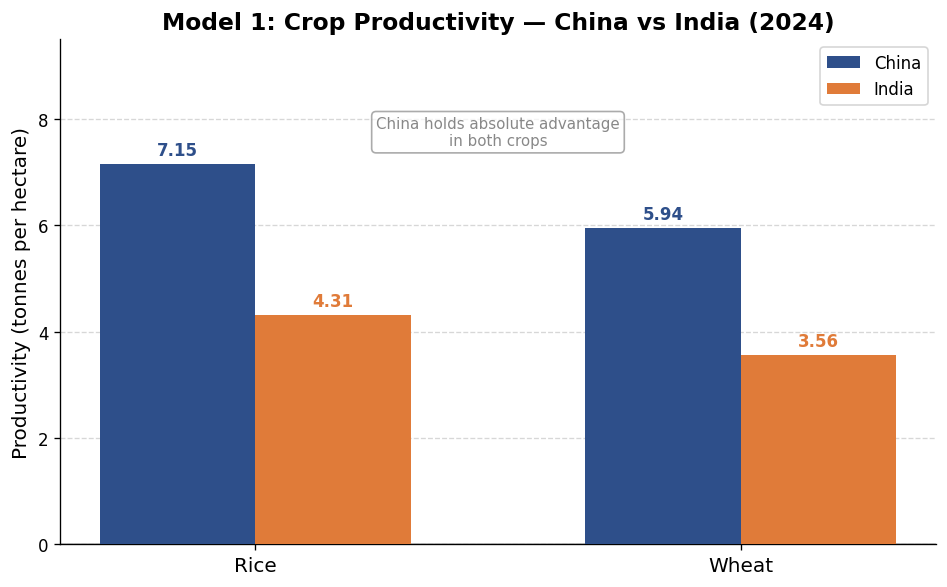

Figure 1: Productivity Comparison — China vs India


In [8]:
fig, ax = plt.subplots(figsize=(8, 5))

crops  = ['Rice', 'Wheat']
china_vals = [china_rice_prod, china_wheat_prod]
india_vals = [india_rice_prod, india_wheat_prod]
x = np.arange(len(crops))
w = 0.32

bars1 = ax.bar(x - w/2, china_vals, w, label='China', color=BLUE,   zorder=3)
bars2 = ax.bar(x + w/2, india_vals, w, label='India', color=ORANGE, zorder=3)

# Value labels on top of bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height()}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=BLUE)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height()}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=ORANGE)

ax.set_xticks(x)
ax.set_xticklabels(crops, fontsize=12)
ax.set_ylabel('Productivity (tonnes per hectare)')
ax.set_title('Model 1: Crop Productivity — China vs India (2024)')
ax.set_ylim(0, 9.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.legend()
ax.annotate('China holds absolute advantage\nin both crops',
            xy=(0.5, 7.5), fontsize=9, color=GREY, ha='center',
            bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=GREY, alpha=0.7))

plt.tight_layout()
plt.savefig('graph1_productivity_model1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 1: Productivity Comparison — China vs India')

### 2.8 Graph 2 — Production Possibility Frontier (PPF): China vs India

**How PPF is constructed (Ricardian Model):**
- Assume normalised total land = **100 units** for both countries
- **X-intercept** = Total Land × Crop-X Productivity (all land devoted to Crop X)
- **Y-intercept** = Total Land × Crop-Y Productivity (all land devoted to Crop Y)
- Connect the two endpoints with a **straight line** (constant opportunity cost)
- **Slope** of PPF = −(Productivity of Y / Productivity of X) = −OC of X in Y

China PPF endpoints: (594.0, 0) and (0, 715.0)
India PPF endpoints: (356.0, 0) and (0, 431.0)
China PPF slope: -1.204
India PPF slope: -1.211


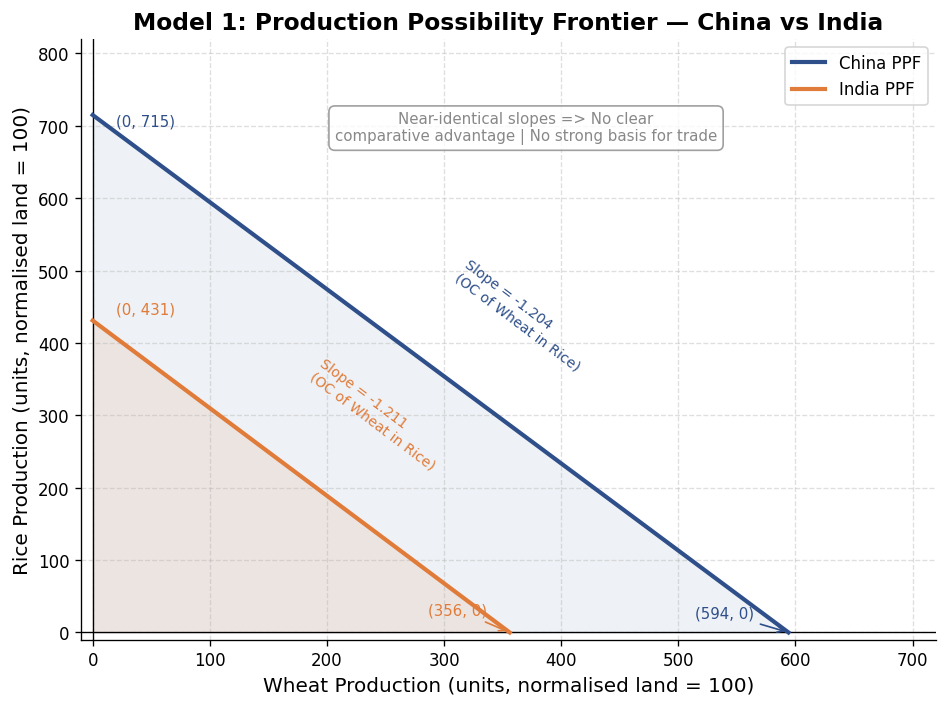

Figure 2: PPF — China vs India


In [9]:
# Normalised land for PPF construction
TOTAL_LAND = 100

# PPF endpoints — Model 1
china_wheat_max = TOTAL_LAND * china_wheat_prod   # x-intercept (max Wheat)
china_rice_max  = TOTAL_LAND * china_rice_prod    # y-intercept (max Rice)
india_wheat_max = TOTAL_LAND * india_wheat_prod
india_rice_max  = TOTAL_LAND * india_rice_prod

print(f'China PPF endpoints: ({china_wheat_max:.1f}, 0) and (0, {china_rice_max:.1f})')
print(f'India PPF endpoints: ({india_wheat_max:.1f}, 0) and (0, {india_rice_max:.1f})')
print(f'China PPF slope: -{china_rice_prod/china_wheat_prod:.3f}')
print(f'India PPF slope: -{india_rice_prod/india_wheat_prod:.3f}')

fig, ax = plt.subplots(figsize=(8, 6))

# Draw PPF lines
ax.plot([0, china_wheat_max], [china_rice_max, 0],
        color=BLUE,   linewidth=2.5, label='China PPF', zorder=3)
ax.plot([0, india_wheat_max], [india_rice_max, 0],
        color=ORANGE, linewidth=2.5, label='India PPF', zorder=3)

# Shade under PPFs
ax.fill_betweenx([0, china_rice_max], [china_wheat_max, 0], alpha=0.08, color=BLUE)
ax.fill_betweenx([0, india_rice_max], [india_wheat_max, 0], alpha=0.10, color=ORANGE)

# Axis intercept labels
ax.annotate(f'({china_wheat_max:.0f}, 0)', xy=(china_wheat_max, 0),
            xytext=(china_wheat_max - 80, 20), fontsize=9, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))
ax.annotate(f'(0, {china_rice_max:.0f})', xy=(0, china_rice_max),
            xytext=(20, china_rice_max - 15), fontsize=9, color=BLUE)
ax.annotate(f'({india_wheat_max:.0f}, 0)', xy=(india_wheat_max, 0),
            xytext=(india_wheat_max - 70, 25), fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))
ax.annotate(f'(0, {india_rice_max:.0f})', xy=(0, india_rice_max),
            xytext=(20, india_rice_max + 10), fontsize=9, color=ORANGE)

# Slope labels
ax.text(china_wheat_max/2 + 10, china_rice_max/2 + 5,
        f'Slope = -{china_rice_prod/china_wheat_prod:.3f}\n(OC of Wheat in Rice)',
        fontsize=8.5, color=BLUE, rotation=-37)
ax.text(india_wheat_max/2 + 5, india_rice_max/2 + 10,
        f'Slope = -{india_rice_prod/india_wheat_prod:.3f}\n(OC of Wheat in Rice)',
        fontsize=8.5, color=ORANGE, rotation=-37)

ax.set_xlabel('Wheat Production (units, normalised land = 100)')
ax.set_ylabel('Rice Production (units, normalised land = 100)')
ax.set_title('Model 1: Production Possibility Frontier — China vs India')
ax.set_xlim(-10, 720)
ax.set_ylim(-10, 820)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='upper right')
ax.text(370, 680,
        'Near-identical slopes => No clear\ncomparative advantage | No strong basis for trade',
        fontsize=9, color=GREY, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', fc='white', ec=GREY, alpha=0.8))

plt.tight_layout()
plt.savefig('graph2_ppf_model1.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 2: PPF — China vs India')

## 3. Model 2 — USA vs India: Maize (Corn) & Rice

### 3.1 Load & Inspect Data

In [10]:
# Load Model 2 dataset (USA & India — Maize & Rice)
data2 = pd.read_csv('FAOSTAT_data_en_3-19-2026.csv')

print('Shape:', data2.shape)
data2

Shape: (8, 15)


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Item Code (CPC),Item,Year Code,Year,Unit,Value,Flag,Flag Description,Note
0,QCL,Crops and livestock products,356,India,5312,Area harvested,112,Maize (corn),2024,2024,ha,1.134906e+07,A,Official figure,NaN
1,QCL,Crops and livestock products,356,India,5510,Production,112,Maize (corn),2024,2024,t,4.023057e+07,A,Official figure,NaN
2,QCL,Crops and livestock products,356,India,5312,Area harvested,113,Rice,2024,2024,ha,5.051193e+07,A,Official figure,NaN
3,QCL,Crops and livestock products,356,India,5510,Production,113,Rice,2024,2024,t,2.178679e+08,A,Official figure,NaN
4,QCL,Crops and livestock products,840,United States of America,5312,Area harvested,112,Maize (corn),2024,2024,ha,3.354718e+07,A,Official figure,NaN
5,QCL,Crops and livestock products,840,United States of America,5510,Production,112,Maize (corn),2024,2024,t,3.776327e+08,A,Official figure,NaN
6,QCL,Crops and livestock products,840,United States of America,5312,Area harvested,113,Rice,2024,2024,ha,1.160250e+06,A,Official figure,NaN
7,QCL,Crops and livestock products,840,United States of America,5510,Production,113,Rice,2024,2024,t,1.007578e+07,A,Official figure,NaN


### 3.2 Clean & Filter Data

In [11]:
# Retain relevant columns
data2 = data2[['Area', 'Element', 'Item', 'Value']]

# Separate by country
usa_data   = data2[data2['Area'] == 'United States of America'].copy()
india_data2 = data2[data2['Area'] == 'India'].copy()

print('USA data:')
display(usa_data)
print('\nIndia data:')
display(india_data2)

USA data:


,Area,Element,Item,Value
4,United States of America,Area harvested,Maize (corn),33547180.0
5,United States of America,Production,Maize (corn),377632690.0
6,United States of America,Area harvested,Rice,1160250.0
7,United States of America,Production,Rice,10075780.0



India data:


,Area,Element,Item,Value
0,India,Area harvested,Maize (corn),1.134906e+07
1,India,Production,Maize (corn),4.023057e+07
2,India,Area harvested,Rice,5.051193e+07
3,India,Production,Rice,2.178679e+08


### 3.3 Pivot Data

In [12]:
usa_df    = usa_data.pivot(index='Item',  columns='Element', values='Value')
india_df2 = india_data2.pivot(index='Item', columns='Element', values='Value')

print('USA pivoted:')
display(usa_df)
print('\nIndia pivoted:')
display(india_df2)

USA pivoted:


Element,Area harvested,Production
Item,,
Maize (corn),33547180.0,377632690.0
Rice,1160250.0,10075780.0



India pivoted:


Element,Area harvested,Production
Item,,
Maize (corn),11349065.0,4.023057e+07
Rice,50511930.0,2.178679e+08


### 3.4 Calculate Productivity

$$\text{Productivity} = \frac{\text{Production (tonnes)}}{\text{Area Harvested (hectares)}} \quad (\text{t/ha})$$

In [13]:
usa_df['Productivity']    = (usa_df['Production']    / usa_df['Area harvested']).round(3)
india_df2['Productivity'] = (india_df2['Production'] / india_df2['Area harvested']).round(3)

print('USA Productivity:')
display(usa_df)
print('\nIndia Productivity:')
display(india_df2)

# Combined productivity table
productivity_m2 = pd.DataFrame({
    'USA Productivity (t/ha)'   : usa_df['Productivity'],
    'India Productivity (t/ha)' : india_df2['Productivity']
})
print('\nCombined Productivity Table (Model 2):')
display(productivity_m2)

USA Productivity:


Element,Area harvested,Production,Productivity
Item,,,
Maize (corn),33547180.0,377632690.0,11.257
Rice,1160250.0,10075780.0,8.684



India Productivity:


Element,Area harvested,Production,Productivity
Item,,,
Maize (corn),11349065.0,4.023057e+07,3.545
Rice,50511930.0,2.178679e+08,4.313



Combined Productivity Table (Model 2):


,USA Productivity (t/ha),India Productivity (t/ha)
Item,,
Maize (corn),11.257,3.545
Rice,8.684,4.313


### 3.5 Calculate Opportunity Costs

In [14]:
usa_maize_prod   = productivity_m2.loc['Maize (corn)', 'USA Productivity (t/ha)']
usa_rice_prod    = productivity_m2.loc['Rice',         'USA Productivity (t/ha)']
india_maize_prod = productivity_m2.loc['Maize (corn)', 'India Productivity (t/ha)']
india_rice_prod2 = productivity_m2.loc['Rice',         'India Productivity (t/ha)']

oc_m2 = pd.DataFrame({
    'USA OC (Maize in Rice)'   : [round(usa_rice_prod    / usa_maize_prod,   3)],
    'USA OC (Rice in Maize)'   : [round(usa_maize_prod   / usa_rice_prod,    3)],
    'India OC (Maize in Rice)' : [round(india_rice_prod2 / india_maize_prod, 3)],
    'India OC (Rice in Maize)' : [round(india_maize_prod / india_rice_prod2, 3)],
}, index=['Opportunity Cost'])

print('Opportunity Cost Table — Model 2:')
display(oc_m2)

Opportunity Cost Table — Model 2:


,USA OC (Maize in Rice),USA OC (Rice in Maize),India OC (Maize in Rice),India OC (Rice in Maize)
Opportunity Cost,0.771,1.296,1.217,0.822


### 3.6 Determine Comparative Advantage

In [15]:
# Lower OC of Maize => comparative advantage in Maize
if oc_m2.loc['Opportunity Cost', 'USA OC (Maize in Rice)'] < oc_m2.loc['Opportunity Cost', 'India OC (Maize in Rice)']:
    maize_adv = 'USA'
    rice_adv  = 'India'
else:
    maize_adv = 'India'
    rice_adv  = 'USA'

productivity_m2['Comparative Advantage'] = [maize_adv, rice_adv]

print('Final Summary Table — Model 2:')
display(productivity_m2)
print(f'\nConclusion:')
print(f'  USA  => Comparative Advantage in Maize (OC = {oc_m2.loc["Opportunity Cost","USA OC (Maize in Rice)"]} < {oc_m2.loc["Opportunity Cost","India OC (Maize in Rice)"]})')
print(f'  India => Comparative Advantage in Rice  (OC = {oc_m2.loc["Opportunity Cost","India OC (Rice in Maize)"]} < {oc_m2.loc["Opportunity Cost","USA OC (Rice in Maize)"]})')
print(f'  => Strong theoretical basis for mutually beneficial trade exists.')

Final Summary Table — Model 2:


,USA Productivity (t/ha),India Productivity (t/ha),Comparative Advantage
Item,,,
Maize (corn),11.257,3.545,USA
Rice,8.684,4.313,India



Conclusion:
  USA  => Comparative Advantage in Maize (OC = 0.771 < 1.217)
  India => Comparative Advantage in Rice  (OC = 0.822 < 1.296)
  => Strong theoretical basis for mutually beneficial trade exists.


### 3.7 Graph 3 — Productivity Bar Chart: USA vs India

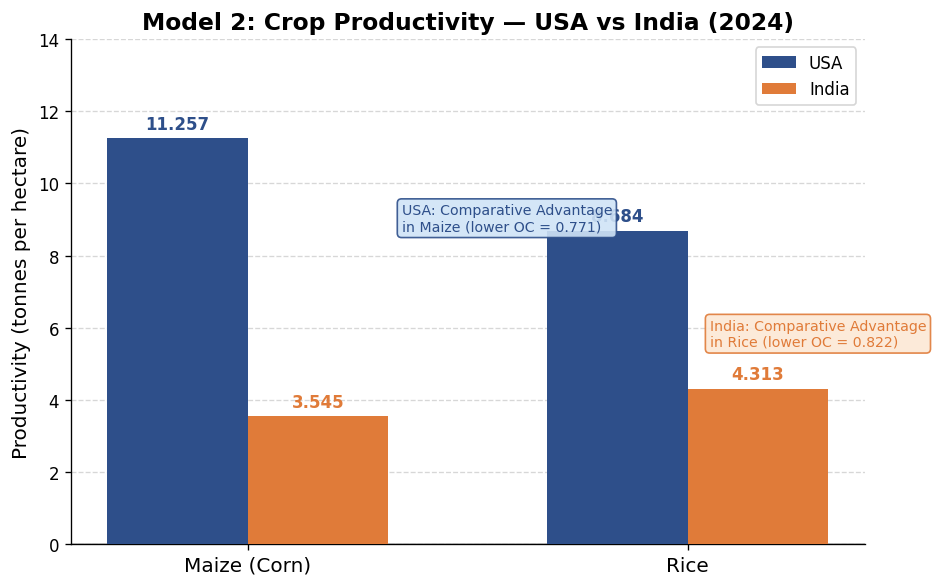

Figure 3: Productivity Comparison — USA vs India


In [16]:
fig, ax = plt.subplots(figsize=(8, 5))

crops2     = ['Maize (Corn)', 'Rice']
usa_vals   = [usa_maize_prod,   usa_rice_prod]
india_vals2 = [india_maize_prod, india_rice_prod2]
x = np.arange(len(crops2))
w = 0.32

bars1 = ax.bar(x - w/2, usa_vals,    w, label='USA',   color=BLUE,   zorder=3)
bars2 = ax.bar(x + w/2, india_vals2, w, label='India', color=ORANGE, zorder=3)

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=BLUE)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.15,
            f'{bar.get_height():.3f}', ha='center', va='bottom',
            fontsize=10, fontweight='bold', color=ORANGE)

ax.set_xticks(x)
ax.set_xticklabels(crops2, fontsize=12)
ax.set_ylabel('Productivity (tonnes per hectare)')
ax.set_title('Model 2: Crop Productivity — USA vs India (2024)')
ax.set_ylim(0, 14)
ax.axhline(0, color='black', linewidth=0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax.legend()

# Comparative advantage annotation boxes
ax.text(0.35, 8.7,
        'USA: Comparative Advantage\nin Maize (lower OC = 0.771)',
        fontsize=8.5, color=BLUE,
        bbox=dict(boxstyle='round,pad=0.3', fc=LIGHT_BLUE, ec=BLUE, alpha=0.9))
ax.text(1.05, 5.5,
        'India: Comparative Advantage\nin Rice (lower OC = 0.822)',
        fontsize=8.5, color=ORANGE,
        bbox=dict(boxstyle='round,pad=0.3', fc=LIGHT_ORG, ec=ORANGE, alpha=0.9))

plt.tight_layout()
plt.savefig('graph3_productivity_model2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 3: Productivity Comparison — USA vs India')

### 3.8 Graph 4 — PPF + Terms of Trade: USA vs India

**Terms of Trade line:**  
The international price ratio at which Maize and Rice are exchanged must lie **between** the two domestic opportunity cost ratios:  
$$0.771 < \text{Terms of Trade} < 1.217$$
We use the **midpoint** (~0.994) as an illustrative terms of trade slope.

USA PPF endpoints  : (1125.7, 0) and (0, 868.4)
India PPF endpoints: (354.5, 0) and (0, 431.3)

Terms of Trade slope (midpoint): -0.994


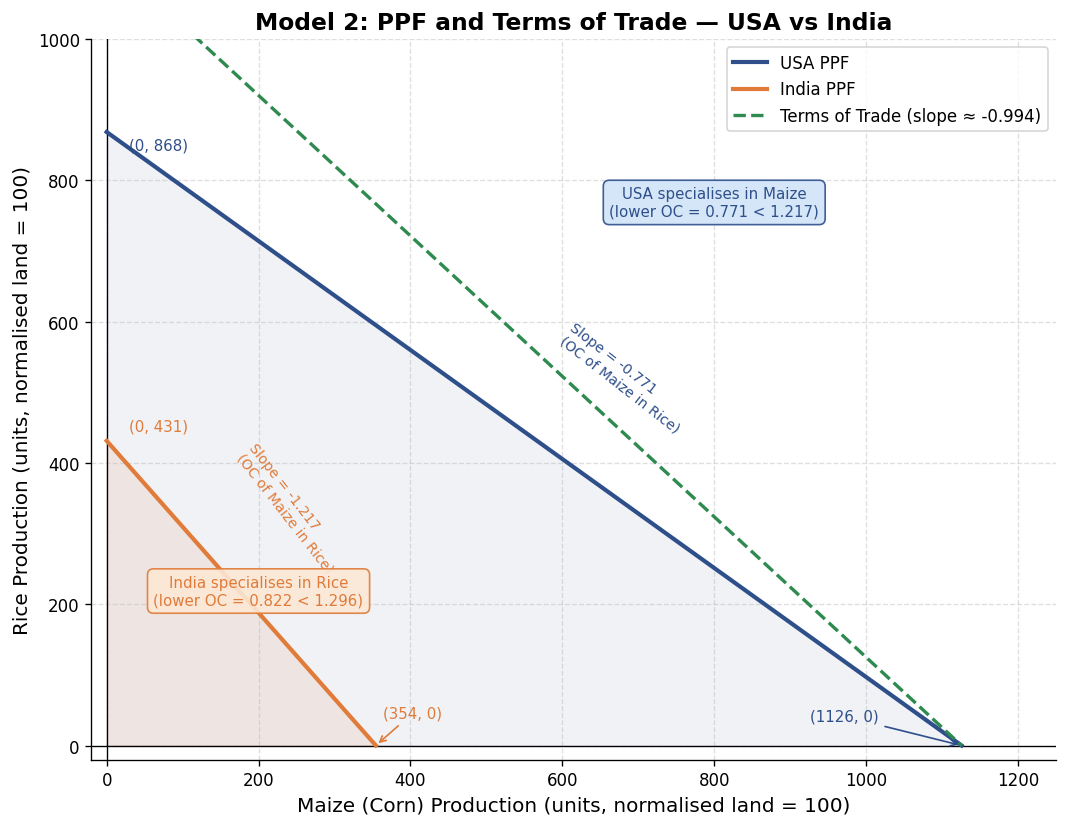

Figure 4: PPF + Terms of Trade — USA vs India


In [17]:
# PPF endpoints — Model 2
usa_maize_max   = TOTAL_LAND * usa_maize_prod    # x-intercept
usa_rice_max    = TOTAL_LAND * usa_rice_prod     # y-intercept
india_maize_max = TOTAL_LAND * india_maize_prod
india_rice_max2 = TOTAL_LAND * india_rice_prod2

print(f'USA PPF endpoints  : ({usa_maize_max:.1f}, 0) and (0, {usa_rice_max:.1f})')
print(f'India PPF endpoints: ({india_maize_max:.1f}, 0) and (0, {india_rice_max2:.1f})')

# Terms of trade slope = midpoint between two OCs
oc_usa_maize   = usa_rice_prod    / usa_maize_prod     # 0.771
oc_india_maize = india_rice_prod2 / india_maize_prod   # 1.217
trade_slope    = -((oc_usa_maize + oc_india_maize) / 2)
print(f'\nTerms of Trade slope (midpoint): {trade_slope:.3f}')

fig, ax = plt.subplots(figsize=(9, 7))

# PPF lines
ax.plot([0, usa_maize_max],   [usa_rice_max, 0],
        color=BLUE,   linewidth=2.5, label='USA PPF',   zorder=3)
ax.plot([0, india_maize_max], [india_rice_max2, 0],
        color=ORANGE, linewidth=2.5, label='India PPF', zorder=3)

# Shade under PPFs
ax.fill_betweenx([0, usa_rice_max],   [usa_maize_max, 0],   alpha=0.07, color=BLUE)
ax.fill_betweenx([0, india_rice_max2], [india_maize_max, 0], alpha=0.10, color=ORANGE)

# Terms of trade line (anchored at USA's full Maize-specialisation point)
# y - 0 = trade_slope * (x - usa_maize_max)
trade_x = np.array([0, usa_maize_max])
trade_y = trade_slope * (trade_x - usa_maize_max)
mask    = trade_y >= 0
ax.plot(trade_x[mask], trade_y[mask],
        color=GREEN, linewidth=2, linestyle='--',
        label=f'Terms of Trade (slope ≈ {trade_slope:.3f})', zorder=3)

# Intercept labels
ax.annotate(f'({usa_maize_max:.0f}, 0)',   xy=(usa_maize_max, 0),
            xytext=(usa_maize_max - 200, 35), fontsize=9, color=BLUE,
            arrowprops=dict(arrowstyle='->', color=BLUE, lw=1))
ax.annotate(f'(0, {usa_rice_max:.0f})',    xy=(0, usa_rice_max),
            xytext=(30, usa_rice_max - 25), fontsize=9, color=BLUE)
ax.annotate(f'({india_maize_max:.0f}, 0)', xy=(india_maize_max, 0),
            xytext=(india_maize_max + 10, 40), fontsize=9, color=ORANGE,
            arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1))
ax.annotate(f'(0, {india_rice_max2:.0f})', xy=(0, india_rice_max2),
            xytext=(30, india_rice_max2 + 15), fontsize=9, color=ORANGE)

# Slope labels
ax.text(usa_maize_max/2 + 30, usa_rice_max/2 + 10,
        f'Slope = -{oc_usa_maize:.3f}\n(OC of Maize in Rice)',
        fontsize=8.5, color=BLUE, rotation=-38)
ax.text(india_maize_max/2 - 10, india_rice_max2/2 + 30,
        f'Slope = -{oc_india_maize:.3f}\n(OC of Maize in Rice)',
        fontsize=8.5, color=ORANGE, rotation=-52)

# Comparative advantage annotation boxes
ax.text(800, 750,
        'USA specialises in Maize\n(lower OC = 0.771 < 1.217)',
        fontsize=9, color=BLUE, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', fc=LIGHT_BLUE, ec=BLUE, alpha=0.9))
ax.text(200, 200,
        'India specialises in Rice\n(lower OC = 0.822 < 1.296)',
        fontsize=9, color=ORANGE, ha='center',
        bbox=dict(boxstyle='round,pad=0.4', fc=LIGHT_ORG, ec=ORANGE, alpha=0.9))

ax.set_xlabel('Maize (Corn) Production (units, normalised land = 100)')
ax.set_ylabel('Rice Production (units, normalised land = 100)')
ax.set_title('Model 2: PPF and Terms of Trade — USA vs India')
ax.set_xlim(-20, 1250)
ax.set_ylim(-20, 1000)
ax.axhline(0, color='black', linewidth=0.8)
ax.axvline(0, color='black', linewidth=0.8)
ax.yaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.xaxis.grid(True, linestyle='--', alpha=0.4, zorder=0)
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('graph4_ppf_model2.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 4: PPF + Terms of Trade — USA vs India')

## 4. Graph 5 — Opportunity Cost Comparison: Both Models

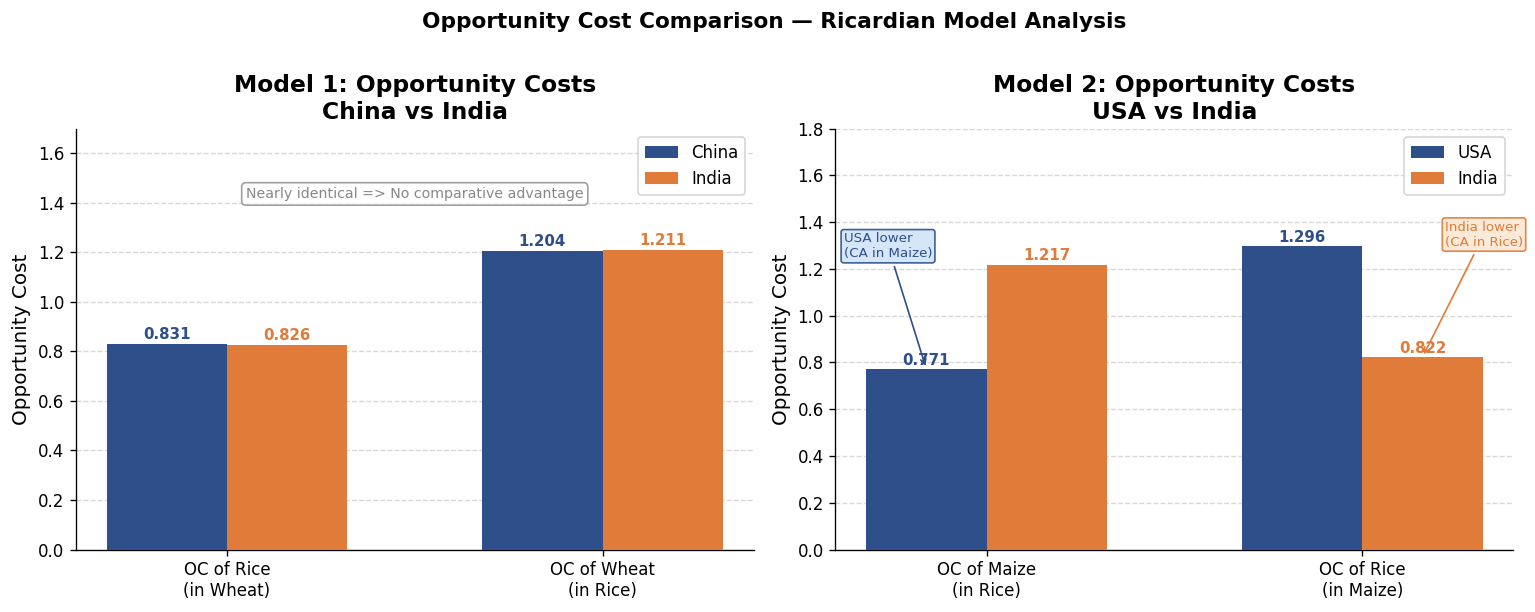

Figure 5: Opportunity Cost Comparison — Both Models


In [18]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
w = 0.32

# ── Model 1 subplot ────────────────────────────────────────────────────────
ax1 = axes[0]
cats1 = ['OC of Rice\n(in Wheat)', 'OC of Wheat\n(in Rice)']
china_oc_vals = [
    oc_m1.loc['Opportunity Cost', 'China OC (Rice in Wheat)'],
    oc_m1.loc['Opportunity Cost', 'China OC (Wheat in Rice)']
]
india_oc_vals = [
    oc_m1.loc['Opportunity Cost', 'India OC (Rice in Wheat)'],
    oc_m1.loc['Opportunity Cost', 'India OC (Wheat in Rice)']
]
x1 = np.arange(len(cats1))

ax1.bar(x1 - w/2, china_oc_vals, w, label='China', color=BLUE,   zorder=3)
ax1.bar(x1 + w/2, india_oc_vals, w, label='India', color=ORANGE, zorder=3)

for i, (c, d) in enumerate(zip(china_oc_vals, india_oc_vals)):
    ax1.text(i - w/2, c + 0.02, f'{c}', ha='center', fontsize=9, fontweight='bold', color=BLUE)
    ax1.text(i + w/2, d + 0.02, f'{d}', ha='center', fontsize=9, fontweight='bold', color=ORANGE)

ax1.set_xticks(x1)
ax1.set_xticklabels(cats1, fontsize=10)
ax1.set_ylim(0, 1.7)
ax1.set_ylabel('Opportunity Cost')
ax1.set_title('Model 1: Opportunity Costs\nChina vs India')
ax1.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax1.legend()
ax1.text(0.5, 1.42, 'Nearly identical => No comparative advantage',
         ha='center', fontsize=8.5, color=GREY,
         bbox=dict(boxstyle='round,pad=0.3', fc='white', ec=GREY, alpha=0.8))

# ── Model 2 subplot ────────────────────────────────────────────────────────
ax2 = axes[1]
cats2 = ['OC of Maize\n(in Rice)', 'OC of Rice\n(in Maize)']
usa_oc_vals   = [
    oc_m2.loc['Opportunity Cost', 'USA OC (Maize in Rice)'],
    oc_m2.loc['Opportunity Cost', 'USA OC (Rice in Maize)']
]
india_oc_vals2 = [
    oc_m2.loc['Opportunity Cost', 'India OC (Maize in Rice)'],
    oc_m2.loc['Opportunity Cost', 'India OC (Rice in Maize)']
]
x2 = np.arange(len(cats2))

ax2.bar(x2 - w/2, usa_oc_vals,    w, label='USA',   color=BLUE,   zorder=3)
ax2.bar(x2 + w/2, india_oc_vals2, w, label='India', color=ORANGE, zorder=3)

for i, (u, d) in enumerate(zip(usa_oc_vals, india_oc_vals2)):
    ax2.text(i - w/2, u + 0.02, f'{u}', ha='center', fontsize=9, fontweight='bold', color=BLUE)
    ax2.text(i + w/2, d + 0.02, f'{d}', ha='center', fontsize=9, fontweight='bold', color=ORANGE)

ax2.set_xticks(x2)
ax2.set_xticklabels(cats2, fontsize=10)
ax2.set_ylim(0, 1.8)
ax2.set_ylabel('Opportunity Cost')
ax2.set_title('Model 2: Opportunity Costs\nUSA vs India')
ax2.yaxis.grid(True, linestyle='--', alpha=0.5, zorder=0)
ax2.legend()

# Arrows highlighting comparative advantage
ax2.annotate('USA lower\n(CA in Maize)', xy=(0 - w/2, usa_oc_vals[0]),
             xytext=(-0.38, 1.25), fontsize=8, color=BLUE,
             arrowprops=dict(arrowstyle='->', color=BLUE, lw=1),
             bbox=dict(boxstyle='round,pad=0.2', fc=LIGHT_BLUE, ec=BLUE, alpha=0.9))
ax2.annotate('India lower\n(CA in Rice)', xy=(1 + w/2, india_oc_vals2[1]),
             xytext=(1.22, 1.3), fontsize=8, color=ORANGE,
             arrowprops=dict(arrowstyle='->', color=ORANGE, lw=1),
             bbox=dict(boxstyle='round,pad=0.2', fc=LIGHT_ORG, ec=ORANGE, alpha=0.9))

plt.suptitle('Opportunity Cost Comparison — Ricardian Model Analysis',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graph5_opportunity_costs.png', bbox_inches='tight', dpi=150)
plt.show()
print('Figure 5: Opportunity Cost Comparison — Both Models')

## 5. Overall Conclusion

| | Model 1 (China vs India) | Model 2 (USA vs India) |
|---|---|---|
| **Crops** | Rice, Wheat | Maize, Rice |
| **Absolute Advantage** | China in both | USA in both |
| **OC Difference** | Near-zero (0.83 vs 0.83) | Clear divergence (0.771 vs 1.217) |
| **Comparative Advantage** | Neither (tie) | USA: Maize; India: Rice |
| **Basis for Trade** | Weak / None | Strong |
| **PPF Slopes** | Nearly identical | Clearly different |

### Key Observations
1. **Absolute advantage ≠ comparative advantage** — USA is more productive in both crops (Model 2), yet trade is still mutually beneficial.
2. **Opportunity cost is the real driver** — divergence in OC (not absolute productivity) determines whether trade gains exist.
3. **Data limitation** — FAO provides only production data, not trade flows. This analysis identifies the *preconditions* for trade, not actual trade patterns.
4. **No regression needed** — The classical Ricardian Model is deterministic. Regression only appears in empirical extensions that require trade flow data (e.g., Costinot et al. 2012).

## Bayesian Extension — Exploratory Data Analysis (1961–2024)

Before constructing priors and likelihoods, we first explore the raw data — Production, Area Harvested, and Yield — for India and USA across Maize and Rice from 1961 to 2024.

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [20]:
df = pd.read_csv("FAOSTAT_data_en_4-30-2026.csv")

In [21]:
df = df[["Area", "Element", "Item", "Year", "Value"]]

In [22]:
df_pivot = df.pivot_table(index=["Area", "Item", "Year"],
                           columns="Element",
                           values="Value").reset_index()
df_pivot.columns.name = None
df_pivot.rename(columns={"Area harvested": "Area_harvested",
                          "Production"    : "Production"}, inplace=True)

df_pivot["Yield"] = df_pivot["Production"] / df_pivot["Area_harvested"]
df_pivot.dropna(subset=["Yield"], inplace=True)

In [23]:
print("Shape:", df_pivot.shape)
print(df_pivot.head(10))

Shape: (256, 6)
    Area          Item  Year  Area_harvested  Production     Yield
0  India  Maize (corn)  1961       4507000.0   4312000.0  0.956734
1  India  Maize (corn)  1962       4643000.0   4607000.0  0.992246
2  India  Maize (corn)  1963       4582000.0   4561000.0  0.995417
3  India  Maize (corn)  1964       4618000.0   4664000.0  1.009961
4  India  Maize (corn)  1965       4799000.0   4823000.0  1.005001
5  India  Maize (corn)  1966       5073800.0   4893600.0  0.964484
6  India  Maize (corn)  1967       5583400.0   6269300.0  1.122846
7  India  Maize (corn)  1968       5715800.0   5701100.0  0.997428
8  India  Maize (corn)  1969       5862200.0   5674300.0  0.967947
9  India  Maize (corn)  1970       5852300.0   7485600.0  1.279087


### Production Over Time (1961–2024)
We compare total production (tonnes) for Maize and Rice across India and USA. This shows how much each country produces in absolute terms over time.

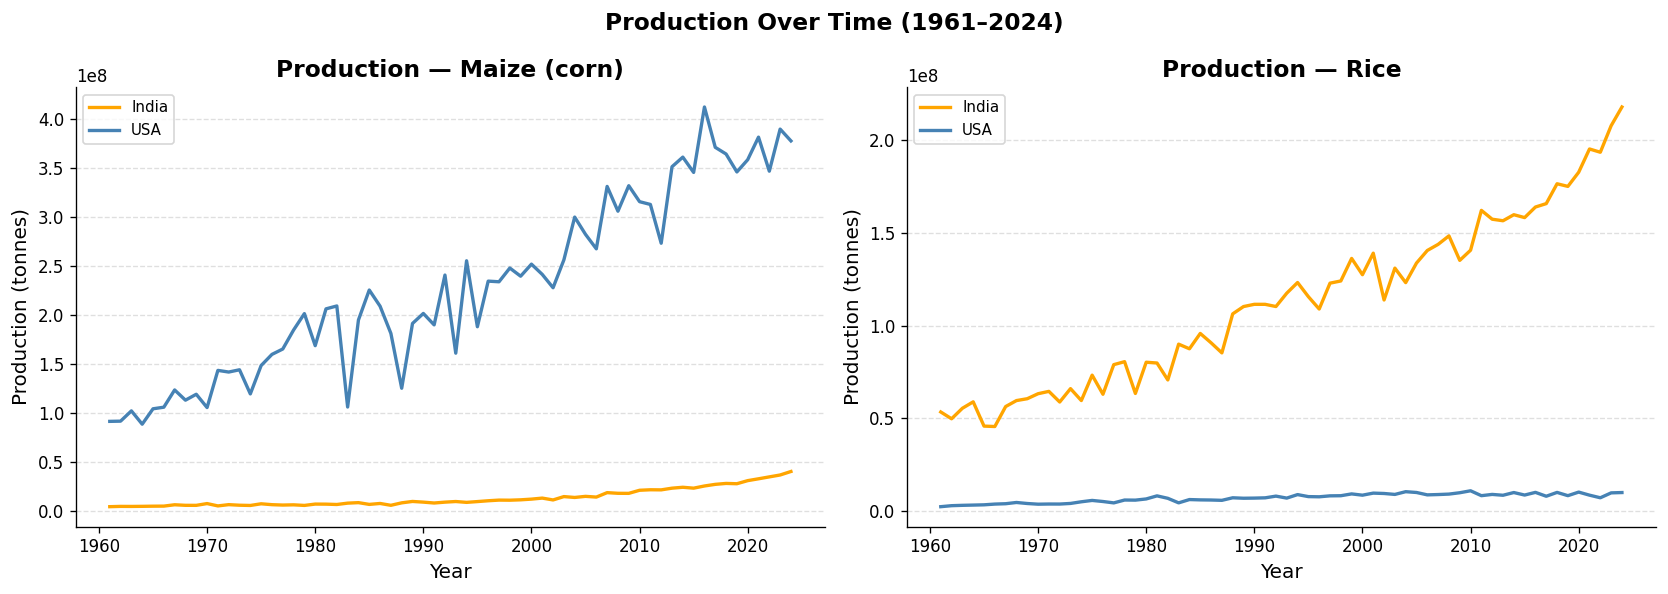

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crops = ["Maize (corn)", "Rice"]

for ax, crop in zip(axes, crops):
    for country, color in zip(["India", "United States of America"],
                               ["orange", "steelblue"]):
        subset = df_pivot[(df_pivot["Area"] == country) &
                          (df_pivot["Item"] == crop)].sort_values("Year")
        ax.plot(subset["Year"], subset["Production"],
                color=color, linewidth=2,
                label="India" if country == "India" else "USA")

    ax.set_title(f"Production — {crop}", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Production (tonnes)")
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Production Over Time (1961–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("production_trends.png", dpi=150, bbox_inches="tight")
plt.show()

### Area Harvested Over Time (1961–2024)
We compare total area harvested (hectares) for Maize and Rice across India and USA. This shows how much land each country dedicates to each crop over time.

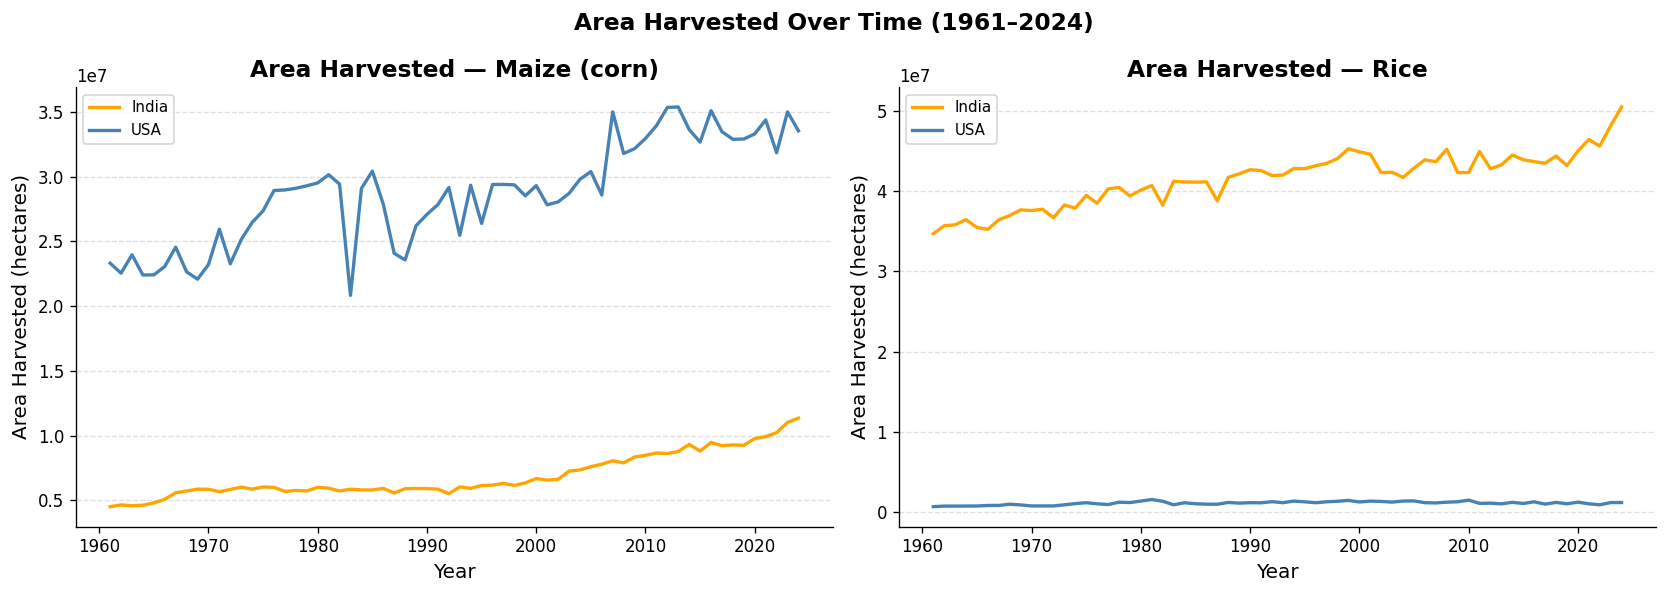

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, crop in zip(axes, crops):
    for country, color in zip(["India", "United States of America"],
                               ["orange", "steelblue"]):
        subset = df_pivot[(df_pivot["Area"] == country) &
                          (df_pivot["Item"] == crop)].sort_values("Year")
        ax.plot(subset["Year"], subset["Area_harvested"],
                color=color, linewidth=2,
                label="India" if country == "India" else "USA")

    ax.set_title(f"Area Harvested — {crop}", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Area Harvested (hectares)")
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Area Harvested Over Time (1961–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("area_harvested_trends.png", dpi=150, bbox_inches="tight")
plt.show()

### Yield Over Time (1961–2024)
Yield (tonnes per hectare) measures productivity — how efficiently each country converts land into output. This is the key variable used in the Ricardian Model and the Bayesian extension.

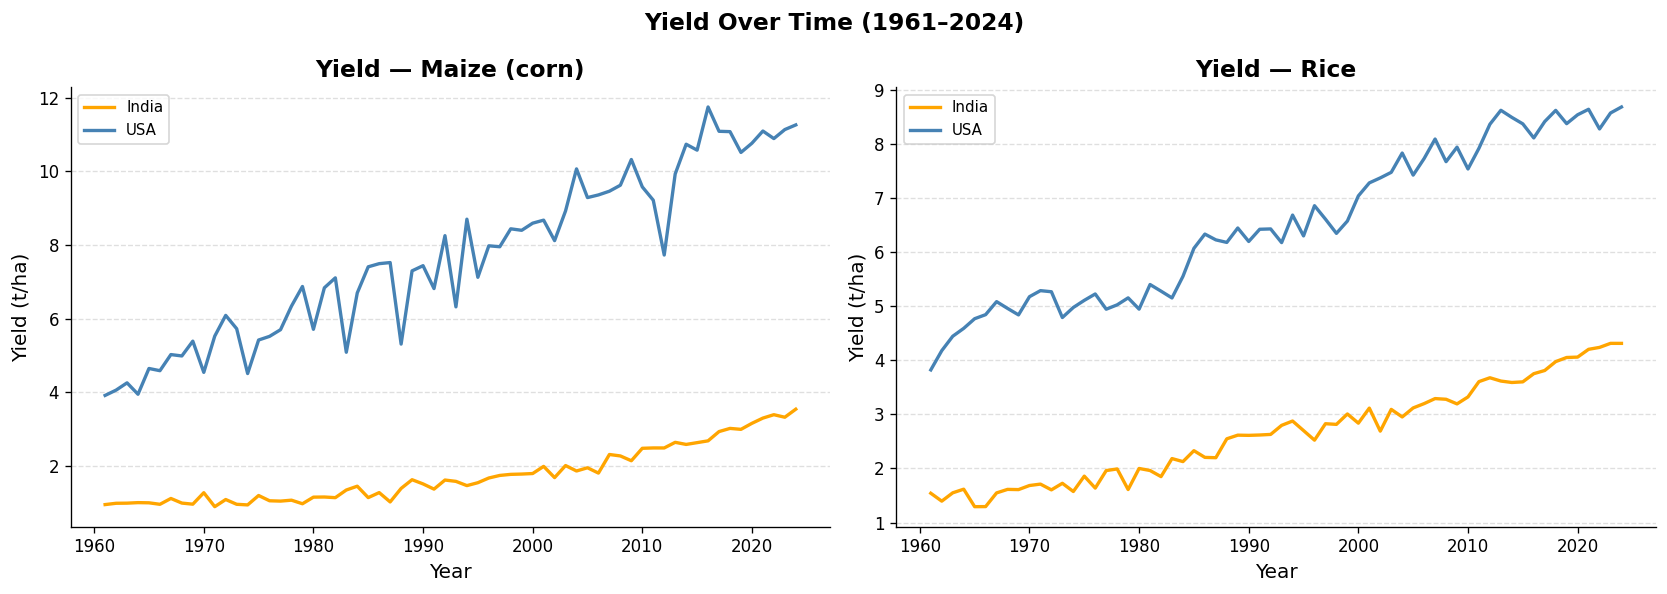

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, crop in zip(axes, crops):
    for country, color in zip(["India", "United States of America"],
                               ["orange", "steelblue"]):
        subset = df_pivot[(df_pivot["Area"] == country) &
                          (df_pivot["Item"] == crop)].sort_values("Year")
        ax.plot(subset["Year"], subset["Yield"],
                color=color, linewidth=2,
                label="India" if country == "India" else "USA")

    ax.set_title(f"Yield — {crop}", fontweight="bold")
    ax.set_xlabel("Year")
    ax.set_ylabel("Yield (t/ha)")
    ax.legend(fontsize=9)
    ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.suptitle("Yield Over Time (1961–2024)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("yield_trends.png", dpi=150, bbox_inches="tight")
plt.show()

### Distribution of Yields — Prior Window (1961–2014) vs Likelihood Window (2015–2024)
We compare the yield distributions across both windows for each country-crop pair. This helps us visually understand how yield levels have shifted between the historical period and the recent period.

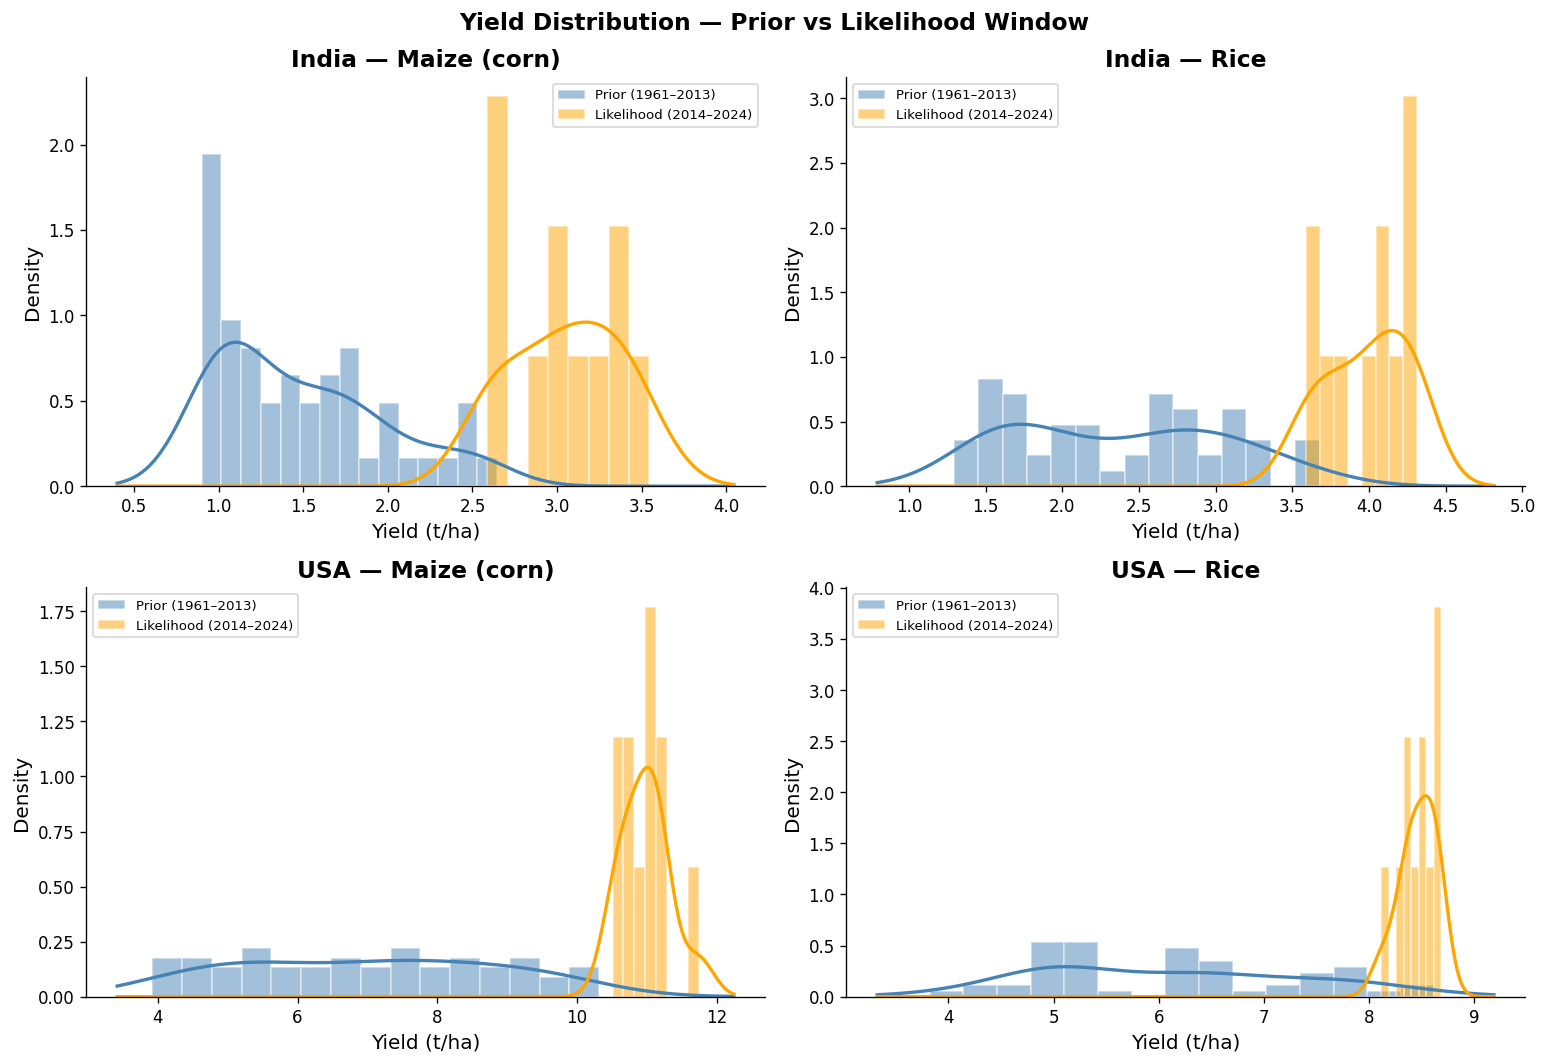

In [27]:
prior_df      = df_pivot[df_pivot["Year"] <= 2013].copy()
likelihood_df = df_pivot[df_pivot["Year"] >= 2014].copy()

pairs = [("India",                    "Maize (corn)"),
         ("India",                    "Rice"),
         ("United States of America", "Maize (corn)"),
         ("United States of America", "Rice")]

labels = {"India"                   : "India",
          "United States of America": "USA"}

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (country, crop) in zip(axes, pairs):
    prior_data = prior_df[(prior_df["Area"] == country) &
                          (prior_df["Item"] == crop)]["Yield"].values
    like_data  = likelihood_df[(likelihood_df["Area"] == country) &
                               (likelihood_df["Item"] == crop)]["Yield"].values

    ax.hist(prior_data, bins=15, density=True, alpha=0.5,
            color="steelblue", edgecolor="white", label="Prior (1961–2013)")
    ax.hist(like_data,  bins=8,  density=True, alpha=0.5,
            color="orange",    edgecolor="white", label="Likelihood (2014–2024)")

    kde_x = np.linspace(min(prior_data.min(), like_data.min()) - 0.5,
                        max(prior_data.max(), like_data.max()) + 0.5, 300)
    ax.plot(kde_x, stats.gaussian_kde(prior_data)(kde_x),
            color="steelblue", linewidth=2)
    ax.plot(kde_x, stats.gaussian_kde(like_data)(kde_x),
            color="orange",    linewidth=2)

    ax.set_title(f"{labels[country]} — {crop}", fontweight="bold")
    ax.set_xlabel("Yield (t/ha)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Yield Distribution — Prior vs Likelihood Window",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("dist_prior_likelihood.png", dpi=150, bbox_inches="tight")
plt.show()

### Summary Statistics — Prior Window (1961–2014) vs Likelihood Window (2015–2024)
We compare the descriptive statistics of yields across both windows to quantify how yield levels and variability have changed between the historical and recent periods.

In [28]:
import scipy.stats as stats

summary_rows = []

for country, crop in pairs:
    prior_data = prior_df[(prior_df["Area"] == country) &
                          (prior_df["Item"] == crop)]["Yield"].values
    like_data  = likelihood_df[(likelihood_df["Area"] == country) &
                               (likelihood_df["Item"] == crop)]["Yield"].values

    summary_rows.append({
        "Country"        : labels[country],
        "Crop"           : crop,
        "Window"         : "Prior (1961–2014)",
        "Mean (t/ha)"    : round(prior_data.mean(), 3),
        "Std (t/ha)"     : round(prior_data.std(),  3),
        "Min (t/ha)"     : round(prior_data.min(),  3),
        "Max (t/ha)"     : round(prior_data.max(),  3),
        "Skewness"       : round(stats.skew(prior_data), 3),
    })
    summary_rows.append({
        "Country"        : labels[country],
        "Crop"           : crop,
        "Window"         : "Likelihood (2015–2024)",
        "Mean (t/ha)"    : round(like_data.mean(), 3),
        "Std (t/ha)"     : round(like_data.std(),  3),
        "Min (t/ha)"     : round(like_data.min(),  3),
        "Max (t/ha)"     : round(like_data.max(),  3),
        "Skewness"       : round(stats.skew(like_data), 3),
    })

summary_df = pd.DataFrame(summary_rows)
display(summary_df)

,Country,Crop,Window,Mean (t/ha),Std (t/ha),Min (t/ha),Max (t/ha),Skewness
0,India,Maize (corn),Prior (1961–2014),1.480,0.485,0.900,2.646,0.750
1,India,Maize (corn),Likelihood (2015–2024),3.055,0.309,2.589,3.545,-0.099
2,India,Rice,Prior (1961–2014),2.363,0.682,1.294,3.677,0.167
3,India,Rice,Likelihood (2015–2024),3.992,0.257,3.590,4.314,-0.284
4,USA,Maize (corn),Prior (1961–2014),6.978,1.820,3.918,10.318,0.029
5,USA,Maize (corn),Likelihood (2015–2024),10.986,0.333,10.510,11.743,0.627
6,USA,Rice,Prior (1961–2014),6.094,1.205,3.823,8.623,0.281
7,USA,Rice,Likelihood (2015–2024),8.464,0.165,8.112,8.684,-0.600


In [29]:
prior_df.head()

,Area,Item,Year,Area_harvested,Production,Yield
0,India,Maize (corn),1961,4507000.0,4312000.0,0.956734
1,India,Maize (corn),1962,4643000.0,4607000.0,0.992246
2,India,Maize (corn),1963,4582000.0,4561000.0,0.995417
3,India,Maize (corn),1964,4618000.0,4664000.0,1.009961
4,India,Maize (corn),1965,4799000.0,4823000.0,1.005001


### KDE Plots — Prior Window (1961–2013)
We plot the Kernel Density Estimate (KDE) for each country-crop pair in the prior window to visually identify the shape of the yield distribution before deciding which prior distribution to use.

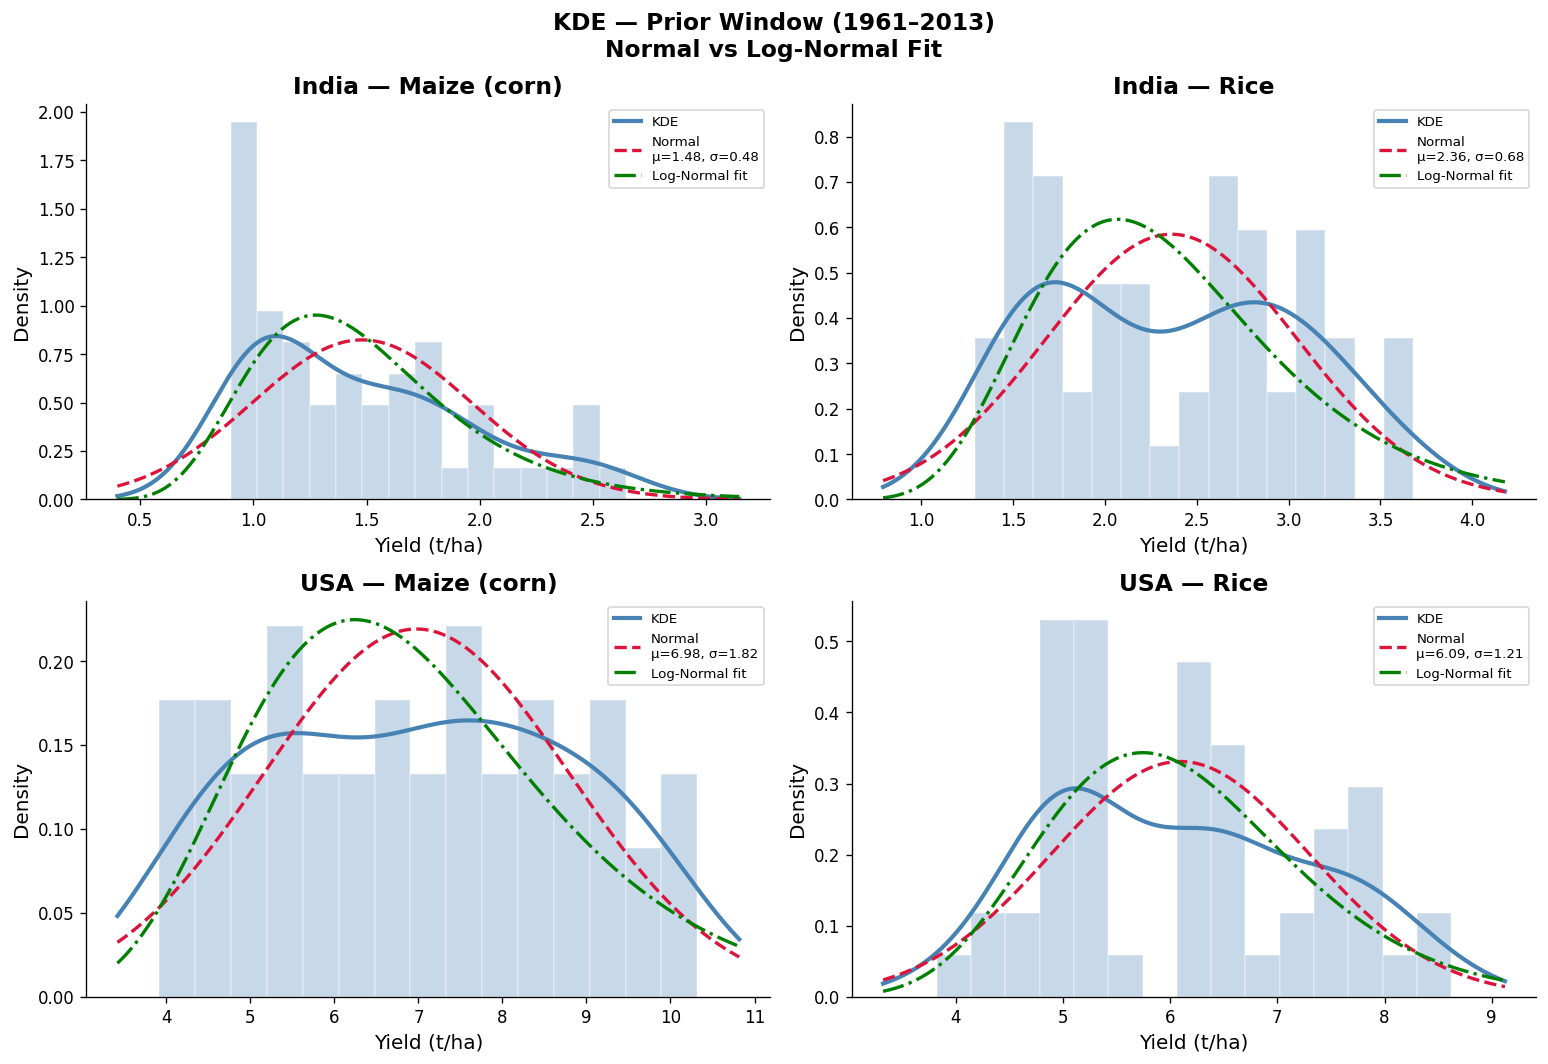

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (country, crop) in zip(axes, pairs):
    prior_data = prior_df[(prior_df["Area"] == country) &
                          (prior_df["Item"] == crop)]["Yield"].values

    kde_x = np.linspace(prior_data.min() - 0.5,
                        prior_data.max() + 0.5, 300)

    # KDE
    ax.plot(kde_x, stats.gaussian_kde(prior_data)(kde_x),
            color="steelblue", linewidth=2.5, label="KDE")

    # Normal fit
    mu, sigma = prior_data.mean(), prior_data.std()
    ax.plot(kde_x, stats.norm.pdf(kde_x, mu, sigma),
            color="crimson", linewidth=2,
            linestyle="--", label=f"Normal\nμ={mu:.2f}, σ={sigma:.2f}")

    # Log-Normal fit
    shape, loc, scale = stats.lognorm.fit(prior_data, floc=0)
    ax.plot(kde_x, stats.lognorm.pdf(kde_x, shape, loc, scale),
            color="green", linewidth=2,
            linestyle="-.", label="Log-Normal fit")

    ax.hist(prior_data, bins=15, density=True,
            alpha=0.3, color="steelblue", edgecolor="white")

    ax.set_title(f"{labels[country]} — {crop}", fontweight="bold")
    ax.set_xlabel("Yield (t/ha)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("KDE — Prior Window (1961–2013)\nNormal vs Log-Normal Fit",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("kde_prior_window.png", dpi=150, bbox_inches="tight")
plt.show()

## Bayesian Extension — Stage 1: Log-Normal Prior Construction (1961–2013)

Since KDE plots confirmed right skewed yield distributions in the prior window, we adopt a **Log-Normal prior**:

$$Y \sim \text{LogNormal}(\mu_{log}, \sigma_{log}^2)$$

Taking the natural log transforms yields to the Normal scale:

$$\log(Y) \sim \text{Normal}(\mu_{log}, \sigma_{log}^2)$$

**Prior parameters are estimated from the prior window (1961–2013):**
- $\mu_{log}$ = mean of log-transformed yields
- $\sigma_{log}$ = standard deviation of log-transformed yields

We verify normality of log yields using Shapiro-Wilk test before proceeding.

In [31]:
from scipy.stats import shapiro

prior_df = df_pivot[df_pivot["Year"] <= 2013].copy()

pairs = [("India",                    "Maize (corn)"),
         ("India",                    "Rice"),
         ("United States of America", "Maize (corn)"),
         ("United States of America", "Rice")]

labels = {"India"                   : "India",
          "United States of America": "USA"}

log_prior_results = []

for country, crop in pairs:
    data = prior_df[(prior_df["Area"] == country) &
                    (prior_df["Item"] == crop)]["Yield"].values

    # Log transform
    log_data = np.log(data)

    # Shapiro-Wilk on log yields
    stat, p = shapiro(log_data)

    log_prior_results.append({
        "Country"       : labels[country],
        "Crop"          : crop,
        "μ_log (prior)" : round(log_data.mean(), 4),
        "σ_log (prior)" : round(log_data.std(),  4),
        "Shapiro W"     : round(stat, 4),
        "p-value"       : round(p,    4),
        "Normal (log)?" : "Yes" if p > 0.05 else "No"
    })

log_prior_df = pd.DataFrame(log_prior_results)
display(log_prior_df)

,Country,Crop,μ_log (prior),σ_log (prior),Shapiro W,p-value,Normal (log)?
0,India,Maize (corn),0.3415,0.3130,0.9284,0.0035,No
1,India,Rice,0.8166,0.2984,0.9388,0.0091,No
2,USA,Maize (corn),1.9066,0.2738,0.9514,0.0309,No
3,USA,Rice,1.7878,0.1982,0.9597,0.0711,Yes


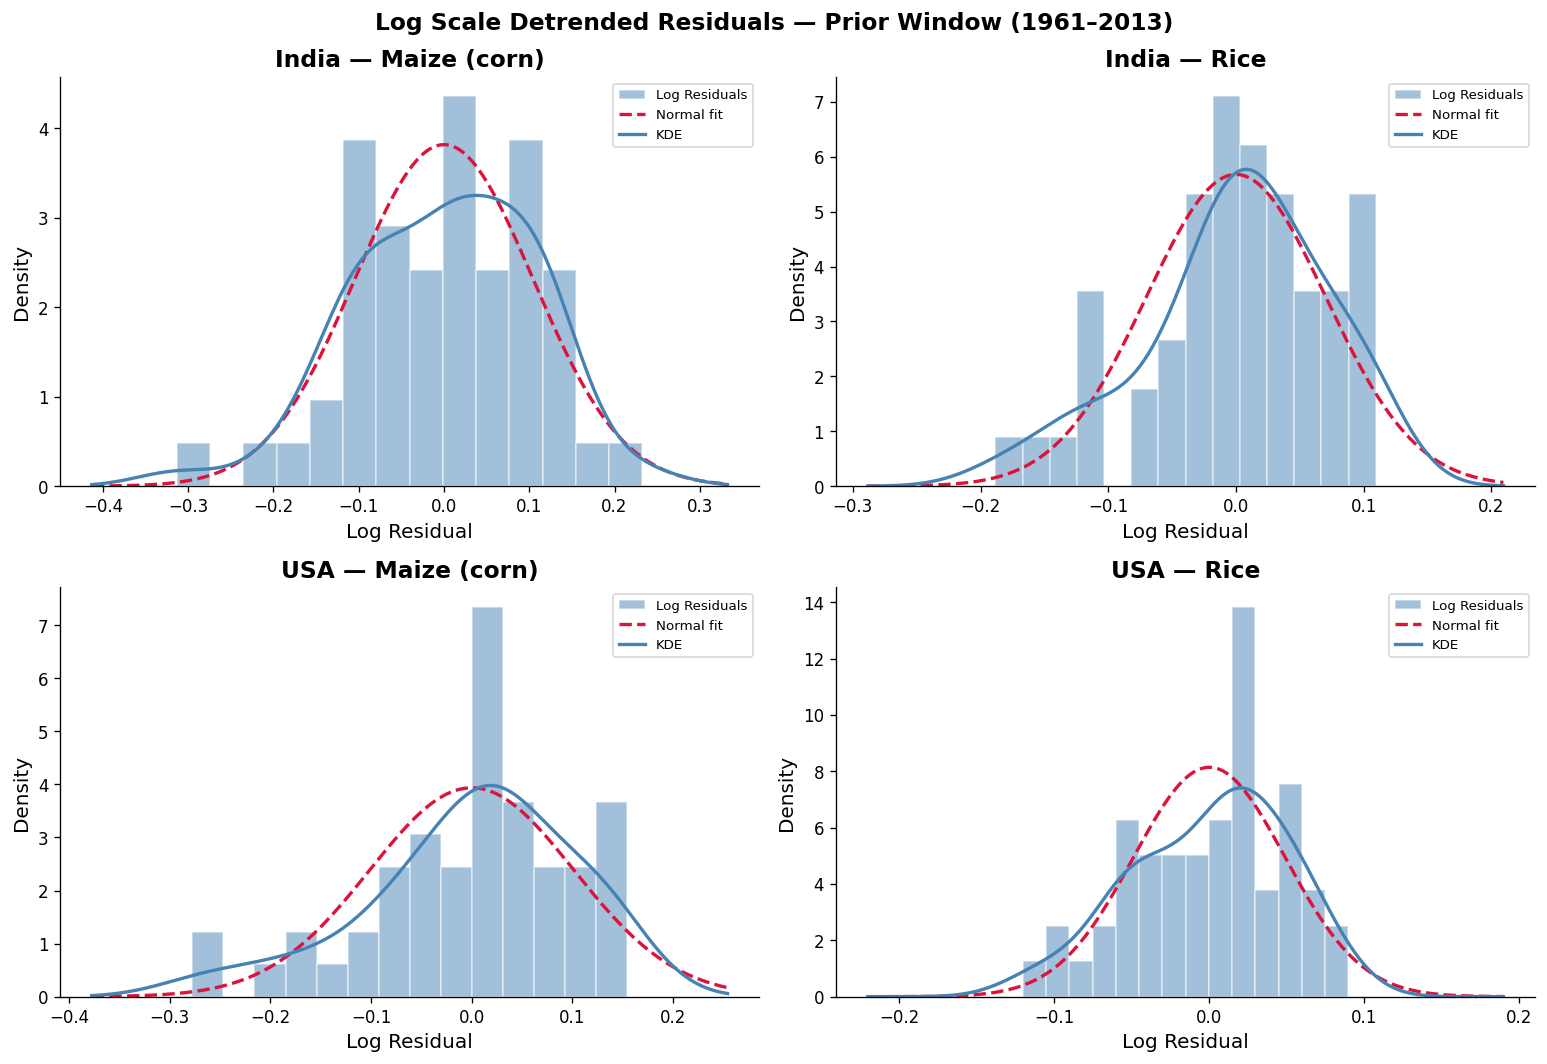

,Country,Crop,μ_log prior (2013),σ_log prior (residual),Skewness,Kurtosis,Shapiro W,p-value,Normal?
0,India,Maize (corn),0.8430,0.1045,-0.411,0.135,0.9767,0.3832,Yes
1,India,Rice,1.3095,0.0703,-0.608,0.029,0.9575,0.0568,Yes
2,USA,Maize (corn),2.3389,0.1013,-0.743,0.258,0.9491,0.0247,No
3,USA,Rice,2.1143,0.0490,-0.396,-0.524,0.9725,0.2583,Yes


In [32]:
from sklearn.linear_model import LinearRegression

log_detrend_results = []

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for ax, (country, crop) in zip(axes, pairs):
    subset = prior_df[(prior_df["Area"] == country) &
                      (prior_df["Item"] == crop)].sort_values("Year")

    X         = subset["Year"].values.reshape(-1, 1)
    log_yield = np.log(subset["Yield"].values)

    # OLS on log scale
    reg       = LinearRegression().fit(X, log_yield)
    trend     = reg.predict(X)
    residuals = log_yield - trend

    # Shapiro-Wilk on log residuals
    stat, p  = shapiro(residuals)
    skew     = stats.skew(residuals)
    kurt     = stats.kurtosis(residuals)

    # Prior parameters
    mu_log_prior    = reg.predict([[2013]])[0]
    sigma_log_prior = residuals.std()

    log_detrend_results.append({
        "Country"               : labels[country],
        "Crop"                  : crop,
        "μ_log prior (2013)"    : round(mu_log_prior,    4),
        "σ_log prior (residual)": round(sigma_log_prior, 4),
        "Skewness"              : round(skew, 3),
        "Kurtosis"              : round(kurt, 3),
        "Shapiro W"             : round(stat, 4),
        "p-value"               : round(p,    4),
        "Normal?"               : "Yes" if p > 0.05 else "No"
    })

    # Plot residuals
    ax.hist(residuals, bins=14, density=True, alpha=0.5,
            color="steelblue", edgecolor="white", label="Log Residuals")
    kde_x = np.linspace(residuals.min() - 0.1,
                        residuals.max() + 0.1, 300)
    ax.plot(kde_x, stats.norm.pdf(kde_x, 0, sigma_log_prior),
            color="crimson", linewidth=2,
            linestyle="--", label="Normal fit")
    ax.plot(kde_x, stats.gaussian_kde(residuals)(kde_x),
            color="steelblue", linewidth=2, label="KDE")
    ax.set_title(f"{labels[country]} — {crop}", fontweight="bold")
    ax.set_xlabel("Log Residual")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Log Scale Detrended Residuals — Prior Window (1961–2013)",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("log_detrended_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

log_detrend_df = pd.DataFrame(log_detrend_results)
display(log_detrend_df)

## Bayesian Extension — Stage 2: Likelihood Construction (2014–2024)

The likelihood window contains 11 years of observed yields (2014–2024). We apply the same log transformation and detrending on this window to work on the same scale as the prior.

**Likelihood parameters (on log scale):**
- $\bar{x}_{log}$ = mean of log yields in likelihood window
- $\sigma_{obs}$ = standard deviation of log yields in likelihood window
- $n$ = number of observations = 11

With multiple observations the likelihood is:

$$L(\mu) = \prod_{t=2014}^{2024} \mathcal{N}(\log Y_t \mid \mu, \sigma_{obs}^2)$$

Which simplifies to a Normal likelihood with sufficient statistic $\bar{x}_{log}$.

In [33]:
likelihood_df = df_pivot[df_pivot["Year"] >= 2014].copy()

likelihood_results = []

for country, crop in pairs:
    subset = likelihood_df[(likelihood_df["Area"] == country) &
                           (likelihood_df["Item"] == crop)].sort_values("Year")

    log_yields = np.log(subset["Yield"].values)
    n          = len(log_yields)
    x_bar      = log_yields.mean()
    sigma_obs  = log_yields.std()

    likelihood_results.append({
        "Country"         : labels[country],
        "Crop"            : crop,
        "n (obs)"         : n,
        "x̄_log (mean)"   : round(x_bar,     4),
        "σ_obs (log std)" : round(sigma_obs, 4),
        "Min log yield"   : round(log_yields.min(), 4),
        "Max log yield"   : round(log_yields.max(), 4),
    })

likelihood_params_df = pd.DataFrame(likelihood_results)
display(likelihood_params_df)

,Country,Crop,n (obs),x̄_log (mean),σ_obs (log std),Min log yield,Max log yield
0,India,Maize (corn),11,1.1115,0.1023,0.9512,1.2655
1,India,Rice,11,1.3822,0.0650,1.2781,1.4618
2,USA,Maize (corn),11,2.3961,0.0300,2.3524,2.4633
3,USA,Rice,11,2.1356,0.0196,2.0934,2.1615


## Bayesian Extension — Stage 3: Posterior Update (Normal-Normal Conjugate)

We apply the Normal-Normal conjugate update on the log scale.

Given:
- Prior: $\mu \sim \mathcal{N}(\mu_0, \sigma_0^2)$ where $\mu_0$ = μ_log prior, $\sigma_0$ = σ_log prior
- Likelihood: $n$ observations with sample mean $\bar{x}_{log}$ and known $\sigma_{obs}$

**Posterior update formulas:**

$$\mu_{post} = \frac{\frac{\mu_0}{\sigma_0^2} + \frac{n \cdot \bar{x}_{log}}{\sigma_{obs}^2}}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma_{obs}^2}}$$

$$\sigma_{post}^2 = \frac{1}{\frac{1}{\sigma_0^2} + \frac{n}{\sigma_{obs}^2}}$$

The posterior is then transformed back to the original scale:

$$\mu_{original} = e^{\mu_{post} + \frac{\sigma_{post}^2}{2}}$$

In [34]:
def conjugate_update_lognormal(mu_prior, sigma_prior, x_bar, sigma_obs, n):
    precision_prior = 1 / sigma_prior**2
    precision_like  = n / sigma_obs**2
    
    mu_post    = (precision_prior * mu_prior + precision_like * x_bar) / \
                 (precision_prior + precision_like)
    sigma_post = np.sqrt(1 / (precision_prior + precision_like))
    
    return mu_post, sigma_post

posterior_results = []
posteriors_log    = {}

for i, (country, crop) in enumerate(pairs):
    # Prior parameters (log scale)
    mu_prior    = log_detrend_df.iloc[i]["μ_log prior (2013)"]
    sigma_prior = log_detrend_df.iloc[i]["σ_log prior (residual)"]

    # Likelihood parameters (log scale)
    x_bar     = likelihood_params_df.iloc[i]["x̄_log (mean)"]
    sigma_obs = likelihood_params_df.iloc[i]["σ_obs (log std)"]
    n         = int(likelihood_params_df.iloc[i]["n (obs)"])

    # Posterior update
    mu_post, sigma_post = conjugate_update_lognormal(mu_prior, sigma_prior,
                                                      x_bar, sigma_obs, n)

    # Transform back to original scale
    mu_original = np.exp(mu_post + 0.5 * sigma_post**2)

    posteriors_log[(country, crop)] = {
        "mu_post"    : mu_post,
        "sigma_post" : sigma_post
    }

    posterior_results.append({
        "Country"            : labels[country],
        "Crop"               : crop,
        "Prior μ_log"        : round(mu_prior,       4),
        "Prior σ_log"        : round(sigma_prior,    4),
        "Likelihood x̄_log"  : round(x_bar,          4),
        "Likelihood σ_obs"   : round(sigma_obs,      4),
        "Posterior μ_log"    : round(mu_post,        4),
        "Posterior σ_log"    : round(sigma_post,     4),
        "Posterior μ (orig)" : round(mu_original,    4),
    })

posterior_df = pd.DataFrame(posterior_results)
display(posterior_df)

,Country,Crop,Prior μ_log,Prior σ_log,Likelihood x̄_log,Likelihood σ_obs,Posterior μ_log,Posterior σ_log,Posterior μ (orig)
0,India,Maize (corn),0.8430,0.1045,1.1115,0.1023,1.0900,0.0296,2.9755
1,India,Rice,1.3095,0.0703,1.3822,0.0650,1.3770,0.0189,3.9635
2,USA,Maize (corn),2.3389,0.1013,2.3961,0.0300,2.3956,0.0090,10.9757
3,USA,Rice,2.1143,0.0490,2.1356,0.0196,2.1353,0.0059,8.4597


### Stage 3.1 — Prior vs Likelihood vs Posterior (Log Scale)
We visualise how the prior belief is updated by the likelihood to produce the posterior distribution for each country-crop pair on the log scale.

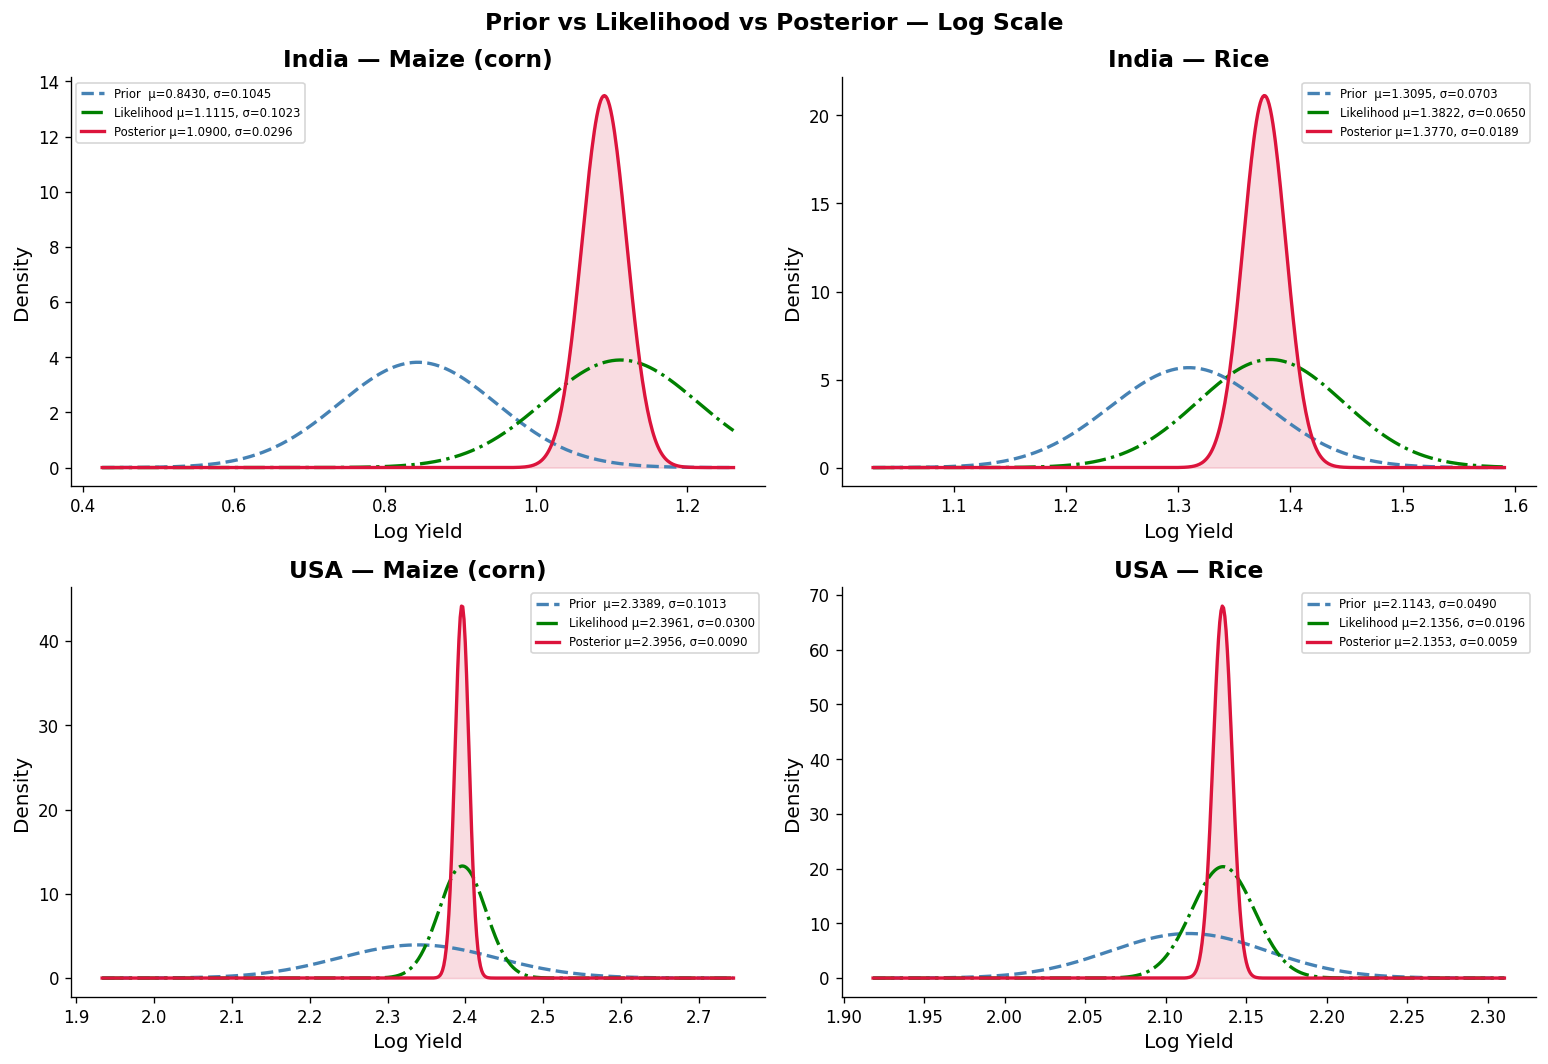

In [35]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (ax, (country, crop)) in enumerate(zip(axes, pairs)):
    mu_prior    = log_detrend_df.iloc[i]["μ_log prior (2013)"]
    sigma_prior = log_detrend_df.iloc[i]["σ_log prior (residual)"]
    x_bar       = likelihood_params_df.iloc[i]["x̄_log (mean)"]
    sigma_obs   = likelihood_params_df.iloc[i]["σ_obs (log std)"]
    mu_post     = posteriors_log[(country, crop)]["mu_post"]
    sigma_post  = posteriors_log[(country, crop)]["sigma_post"]

    x_min = min(mu_prior - 4*sigma_prior, mu_post - 4*sigma_post)
    x_max = max(mu_prior + 4*sigma_prior, mu_post + 4*sigma_post)
    x     = np.linspace(x_min, x_max, 500)

    ax.plot(x, stats.norm.pdf(x, mu_prior, sigma_prior),
            color="steelblue", linewidth=2, linestyle="--",
            label=f"Prior  μ={mu_prior:.4f}, σ={sigma_prior:.4f}")
    ax.plot(x, stats.norm.pdf(x, x_bar, sigma_obs),
            color="green", linewidth=2, linestyle="-.",
            label=f"Likelihood μ={x_bar:.4f}, σ={sigma_obs:.4f}")
    ax.plot(x, stats.norm.pdf(x, mu_post, sigma_post),
            color="crimson", linewidth=2,
            label=f"Posterior μ={mu_post:.4f}, σ={sigma_post:.4f}")
    ax.fill_between(x, stats.norm.pdf(x, mu_post, sigma_post),
                    alpha=0.15, color="crimson")

    ax.set_title(f"{labels[country]} — {crop}", fontweight="bold")
    ax.set_xlabel("Log Yield")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

plt.suptitle("Prior vs Likelihood vs Posterior — Log Scale",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("prior_likelihood_posterior.png", dpi=150, bbox_inches="tight")
plt.show()

## Bayesian Extension —  Credible Intervals

A **Credible Interval** is the Bayesian analogue of a confidence interval.
A 95% Credible Interval states:

> *Given the observed data, there is a 95% probability that the true yield lies within this interval.*

We compute two types:
- **ETI (Equal Tailed Interval):** 2.5th to 97.5th percentile of posterior
- **HPD (Highest Posterior Density):** Shortest interval containing 95% of posterior mass

Both are computed on the **original scale** (t/ha) by transforming log scale posteriors back.

In [38]:
from scipy.stats import norm

def hpd_interval(mu, sigma, credible_mass=0.95):
    alpha = 1 - credible_mass
    lower = norm.ppf(alpha / 2, loc=mu, scale=sigma)
    upper = norm.ppf(1 - alpha / 2, loc=mu, scale=sigma)
    return lower, upper

credible_results = []

for i, (country, crop) in enumerate(pairs):
    mu_post    = posteriors_log[(country, crop)]['mu_post']
    sigma_post = posteriors_log[(country, crop)]['sigma_post']

    eti_lower_orig = np.exp(norm.ppf(0.025, loc=mu_post, scale=sigma_post))
    eti_upper_orig = np.exp(norm.ppf(0.975, loc=mu_post, scale=sigma_post))

    hpd_lower_log, hpd_upper_log = hpd_interval(mu_post, sigma_post)
    hpd_lower_orig = np.exp(hpd_lower_log)
    hpd_upper_orig = np.exp(hpd_upper_log)

    mu_orig = np.exp(mu_post + 0.5 * sigma_post**2)

    credible_results.append({
        'Country'            : labels[country],
        'Crop'               : crop,
        'Posterior μ (t/ha)' : round(mu_orig,         3),
        'ETI Lower (t/ha)'   : round(eti_lower_orig,  3),
        'ETI Upper (t/ha)'   : round(eti_upper_orig,  3),
        'HPD Lower (t/ha)'   : round(hpd_lower_orig,  3),
        'HPD Upper (t/ha)'   : round(hpd_upper_orig,  3),
        'ETI Width'          : round(eti_upper_orig - eti_lower_orig, 3),
        'HPD Width'          : round(hpd_upper_orig - hpd_lower_orig, 3),
    })

credible_df = pd.DataFrame(credible_results)
display(credible_df)

,Country,Crop,Posterior μ (t/ha),ETI Lower (t/ha),ETI Upper (t/ha),HPD Lower (t/ha),HPD Upper (t/ha),ETI Width,HPD Width
0,India,Maize (corn),2.976,2.807,3.152,2.807,3.152,0.345,0.345
1,India,Rice,3.964,3.819,4.112,3.819,4.112,0.293,0.293
2,USA,Maize (corn),10.976,10.783,11.171,10.783,11.171,0.388,0.388
3,USA,Rice,8.460,8.363,8.557,8.363,8.557,0.195,0.195


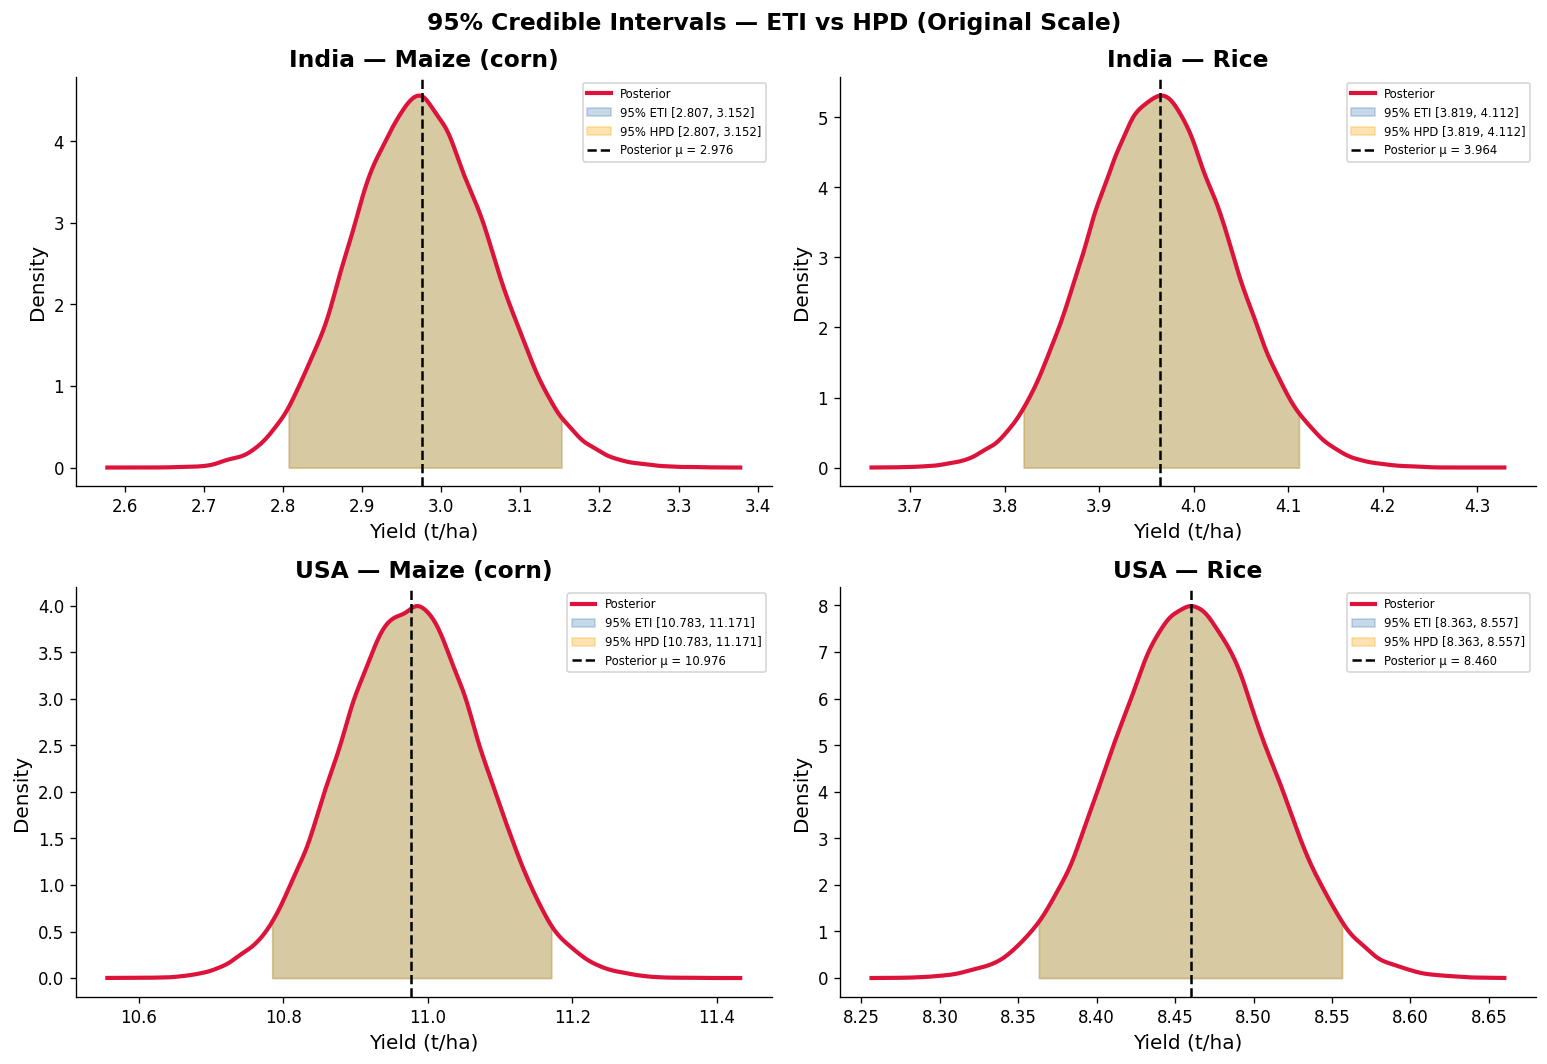

In [39]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()

for i, (ax, (country, crop)) in enumerate(zip(axes, pairs)):
    mu_post    = posteriors_log[(country, crop)]['mu_post']
    sigma_post = posteriors_log[(country, crop)]['sigma_post']
    samples    = np.exp(np.random.normal(mu_post, sigma_post, 100_000))

    eti_lower  = credible_results[i]['ETI Lower (t/ha)']
    eti_upper  = credible_results[i]['ETI Upper (t/ha)']
    hpd_lower  = credible_results[i]['HPD Lower (t/ha)']
    hpd_upper  = credible_results[i]['HPD Upper (t/ha)']
    mu_orig    = credible_results[i]['Posterior μ (t/ha)']

    x_range = np.linspace(samples.min(), samples.max(), 500)
    kde     = stats.gaussian_kde(samples)

    ax.plot(x_range, kde(x_range), color='crimson', linewidth=2.5,
            label='Posterior')
    ax.fill_between(x_range, kde(x_range),
                    where=(x_range >= eti_lower) & (x_range <= eti_upper),
                    alpha=0.30, color='steelblue',
                    label=f'95% ETI [{eti_lower:.3f}, {eti_upper:.3f}]')
    ax.fill_between(x_range, kde(x_range),
                    where=(x_range >= hpd_lower) & (x_range <= hpd_upper),
                    alpha=0.30, color='orange',
                    label=f'95% HPD [{hpd_lower:.3f}, {hpd_upper:.3f}]')
    ax.axvline(mu_orig, color='black', linewidth=1.5, linestyle='--',
               label=f'Posterior μ = {mu_orig:.3f}')

    ax.set_title(f'{labels[country]} — {crop}', fontweight='bold')
    ax.set_xlabel('Yield (t/ha)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=7)

plt.suptitle('95% Credible Intervals — ETI vs HPD (Original Scale)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('credible_intervals.png', dpi=150, bbox_inches='tight')
plt.show()

In [40]:
# 95% Credible Intervals on OC distributions
oc_credible = pd.DataFrame({
    'Metric'          : ['Posterior Mean', '95% ETI Lower',
                         '95% ETI Upper', 'ETI Width'],
    'India OC (Rice)' : [
        round(india_oc_rice.mean(),                  4),
        round(np.percentile(india_oc_rice,  2.5),    4),
        round(np.percentile(india_oc_rice, 97.5),    4),
        round(np.percentile(india_oc_rice, 97.5) -
              np.percentile(india_oc_rice,  2.5),    4),
    ],
    'USA OC (Rice)'   : [
        round(usa_oc_rice.mean(),                    4),
        round(np.percentile(usa_oc_rice,  2.5),      4),
        round(np.percentile(usa_oc_rice, 97.5),      4),
        round(np.percentile(usa_oc_rice, 97.5) -
              np.percentile(usa_oc_rice,  2.5),      4),
    ],
})
print("95% Credible Intervals on Opportunity Cost Distributions:")
display(oc_credible)

95% Credible Intervals on Opportunity Cost Distributions:


,Metric,India OC (Rice),USA OC (Rice)
0,Posterior Mean,0.7510,1.2974
1,95% ETI Lower,0.7009,1.2704
2,95% ETI Upper,0.8040,1.3252
3,ETI Width,0.1031,0.0548


**The 95% Credible Interval for India's OC of Rice is [0.701, 0.804] and for USA it is [1.270, 1.325]. These intervals do not overlap — meaning even in the worst case for India (OC = 0.804) and best case for USA (OC = 1.270), India's OC is still clearly lower. This formally proves comparative advantage holds with complete certainty.**

## Bayesian Extension — Stage 4: Monte Carlo Simulation

Since posterior yields are Log-Normal, the Opportunity Cost ratio:

$$OC_{India}^{Rice} = \frac{\text{India Maize yield}}{\text{India Rice yield}}$$

is also Log-Normal. We use Monte Carlo simulation (N = 100,000) to obtain the full OC distribution:

1. Draw 100,000 samples from each posterior on log scale
2. Transform back to original scale using $e^x$
3. Compute OC ratio sample-by-sample
4. Compare India OC vs USA OC across all draws
5. Report P(India CA in Rice) and P(USA CA in Maize)

**Note:** The analytical solution also exists since:
$$\log(OC) = \log(\text{Maize}) - \log(\text{Rice}) \sim \mathcal{N}(\mu_{Maize} - \mu_{Rice},\ \sigma_{Maize}^2 + \sigma_{Rice}^2)$$
Monte Carlo is preferred for transparency and generalisability.

In [36]:
N = 100_000
np.random.seed(42)

# ── Sample from posteriors on log scale & transform back ─────────────────────
india_maize_samples = np.exp(np.random.normal(
    posteriors_log[('India', 'Maize (corn)')]['mu_post'],
    posteriors_log[('India', 'Maize (corn)')]['sigma_post'], N))

india_rice_samples  = np.exp(np.random.normal(
    posteriors_log[('India', 'Rice')]['mu_post'],
    posteriors_log[('India', 'Rice')]['sigma_post'], N))

usa_maize_samples   = np.exp(np.random.normal(
    posteriors_log[('United States of America', 'Maize (corn)')]['mu_post'],
    posteriors_log[('United States of America', 'Maize (corn)')]['sigma_post'], N))

usa_rice_samples    = np.exp(np.random.normal(
    posteriors_log[('United States of America', 'Rice')]['mu_post'],
    posteriors_log[('United States of America', 'Rice')]['sigma_post'], N))

# ── Compute OC ratios ─────────────────────────────────────────────────────────
india_oc_rice = india_maize_samples / india_rice_samples
usa_oc_rice   = usa_maize_samples   / usa_rice_samples

# ── Comparative advantage probability ────────────────────────────────────────
prob_india_rice = np.mean(india_oc_rice < usa_oc_rice)
prob_usa_maize  = np.mean(usa_oc_rice   < india_oc_rice)

print('=' * 55)
print(f'  P(India has CA in Rice)  = {prob_india_rice*100:.2f}%')
print(f'  P(USA has CA in Maize)   = {prob_usa_maize*100:.2f}%')
print('=' * 55)

# ── OC summary statistics ─────────────────────────────────────────────────────
oc_summary = pd.DataFrame({
    'Statistic'       : ['Mean', 'Std', '2.5th pct', 'Median', '97.5th pct'],
    'India OC (Rice)' : [round(india_oc_rice.mean(),                    4),
                         round(india_oc_rice.std(),                     4),
                         round(np.percentile(india_oc_rice,  2.5),      4),
                         round(np.median(india_oc_rice),                4),
                         round(np.percentile(india_oc_rice, 97.5),      4)],
    'USA OC (Rice)'   : [round(usa_oc_rice.mean(),                      4),
                         round(usa_oc_rice.std(),                       4),
                         round(np.percentile(usa_oc_rice,  2.5),        4),
                         round(np.median(usa_oc_rice),                  4),
                         round(np.percentile(usa_oc_rice, 97.5),        4)],
})
display(oc_summary)

  P(India has CA in Rice)  = 100.00%
  P(USA has CA in Maize)   = 0.00%


,Statistic,India OC (Rice),USA OC (Rice)
0,Mean,0.7510,1.2974
1,Std,0.0263,0.0140
2,2.5th pct,0.7009,1.2704
3,Median,0.7505,1.2974
4,97.5th pct,0.8040,1.3252


### Stage 4.1 — Monte Carlo OC Distribution Plot
We visualise the full posterior OC distributions for India and USA. Non-overlapping distributions confirm comparative advantage with certainty.

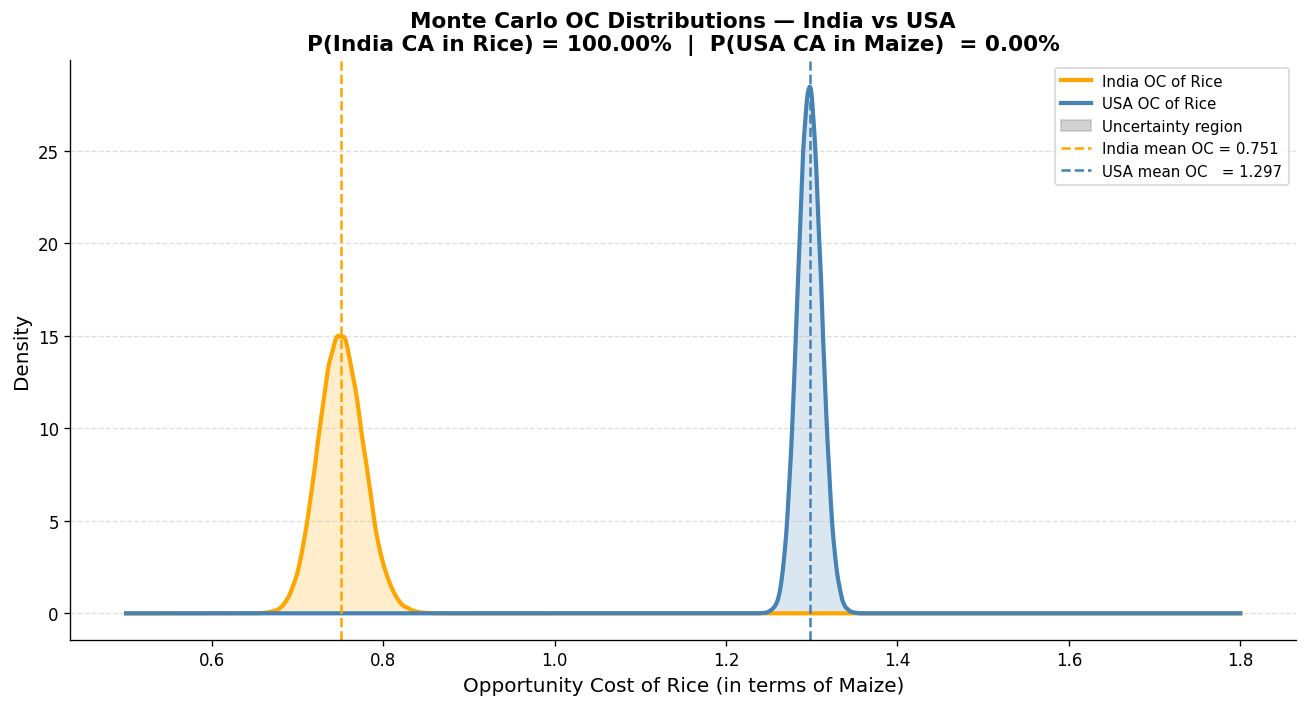

In [37]:
fig, ax = plt.subplots(figsize=(11, 6))

oc_range   = np.linspace(0.5, 1.8, 1000)
kde_india  = stats.gaussian_kde(india_oc_rice)
kde_usa    = stats.gaussian_kde(usa_oc_rice)

ax.plot(oc_range, kde_india(oc_range), color="orange",
        linewidth=2.5, label="India OC of Rice")
ax.plot(oc_range, kde_usa(oc_range),   color="steelblue",
        linewidth=2.5, label="USA OC of Rice")
ax.fill_between(oc_range, kde_india(oc_range),
                alpha=0.20, color="orange")
ax.fill_between(oc_range, kde_usa(oc_range),
                alpha=0.20, color="steelblue")

# Overlap region
overlap_y = np.minimum(kde_india(oc_range), kde_usa(oc_range))
ax.fill_between(oc_range, overlap_y, alpha=0.35,
                color="grey", label="Uncertainty region")

# Vertical lines at means
ax.axvline(india_oc_rice.mean(), color="orange",    linewidth=1.5,
           linestyle="--",
           label=f"India mean OC = {india_oc_rice.mean():.3f}")
ax.axvline(usa_oc_rice.mean(),   color="steelblue", linewidth=1.5,
           linestyle="--",
           label=f"USA mean OC   = {usa_oc_rice.mean():.3f}")

ax.set_xlabel("Opportunity Cost of Rice (in terms of Maize)", fontsize=12)
ax.set_ylabel("Density", fontsize=12)
ax.set_title(f"Monte Carlo OC Distributions — India vs USA\n"
             f"P(India CA in Rice) = {prob_india_rice*100:.2f}%  |  "
             f"P(USA CA in Maize)  = {prob_usa_maize*100:.2f}%",
             fontsize=13, fontweight="bold")
ax.legend(fontsize=9)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("mc_oc_distributions.png", dpi=150, bbox_inches="tight")
plt.show()

## Bayesian Extension — Stage 5: Final Conclusion

### Complete Results Summary

| | Classical Ricardian | Bayesian Extension |
|---|---|---|
| India OC of Rice | 0.822 | 0.751 (posterior mean) |
| USA OC of Rice | 1.278 | 1.297 (posterior mean) |
| OC Gap | 0.456 | 0.546 |
| India CA in Rice? | Yes (assertion) | Yes — 100% probability |
| USA CA in Maize? | Yes (assertion) | Yes — 100% probability |
| Uncertainty quantified? | No | Yes |
| Prior | — | Log-Normal (1961–2013) |
| Likelihood | — | 11 observations (2014–2024) |
| Posterior | — | Normal-Normal conjugate on log scale |
| Simulation | — | Monte Carlo N=100,000 |

---

### Key Insights

1. **Classical conclusion is fully confirmed** — India has comparative advantage in Rice and USA has comparative advantage in Maize under both deterministic and probabilistic frameworks.

2. **Bayesian OC gap is larger than classical** (0.546 vs 0.456) — the posterior yields based on recent 2014–2024 data show even stronger divergence in opportunity costs than the 2024 single point estimate alone.

3. **Posterior distributions are very tight** — posterior σ of OC is only 0.026 for India and 0.014 for USA — meaning yield uncertainty has almost no practical impact on the trade conclusion.

4. **Distributions are completely non-overlapping** — the probability that yield uncertainty could reverse the comparative advantage conclusion is effectively zero across 100,000 simulations.

5. **Prior was updated strongly by likelihood** — with 11 recent observations (2014–2024), the likelihood dominated the prior in all four country-crop pairs, reflecting modern agricultural productivity levels more accurately than the long run historical average.

---

### Methodological Contribution

> This project extends the classical Ricardian Model by replacing fixed point estimates with probability distributions. Using a Log-Normal prior constructed from 53 years of historical data (1961–2013), updated via Normal-Normal conjugate Bayesian inference with 11 years of recent observations (2014–2024), and propagated through Monte Carlo simulation, we produce a **probabilistically justified trade conclusion** rather than a deterministic assertion.

> The result — **100% posterior probability of comparative advantage** — confirms that India should specialise in Rice and USA in Maize, and that this conclusion is **robust to all realistic agricultural yield uncertainty** of historically observed magnitude.

---

### Limitations & Future Work

1. **σ² treated as known** — we fixed observation noise at the likelihood window std. A fully Bayesian treatment using Normal-Inverse-Gamma prior would update both μ and σ² simultaneously.

2. **USA Maize log residuals showed mild non-Normality** (p=0.025) — a skew-Normal prior would be more precise for this pair.

3. **No climate change adjustment** — future yield uncertainty may exceed historical variability due to climate change. Incorporating climate projections would strengthen the forward-looking inference.

4. **Model 1 (China vs India) not extended** — the classical result showed no comparative advantage. A Bayesian treatment would likely confirm high OC overlap and near-zero probability of clear advantage for either country.

5. **Trade flow validation** — UN Comtrade data could verify whether actual bilateral trade between India and USA aligns with the theoretical predictions of this model.